In [48]:
!pip install -q "scanpy==1.10.3"

In [49]:
import scanpy as sc

print("Scanpy version:", sc.__version__)

Scanpy version: 1.10.3


In [50]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Scanpy version:", sc.__version__)

Scanpy version: 1.10.3


In [51]:
adata = sc.datasets.pbmc3k()

print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)


/usr/local/lib/python3.13/dist-packages/scanpy/datasets/_utils.py:37: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(ad.__version__).release >= (0, 8):


In [52]:
adata.obs.head()

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [53]:
print("Number of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

Number of cells: 2700
Number of genes: 32738


In [54]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate quality-control metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

# Display the first few cells with QC metrics
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850148,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242


In [55]:
adata.obs[[
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt"
]].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.261963,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


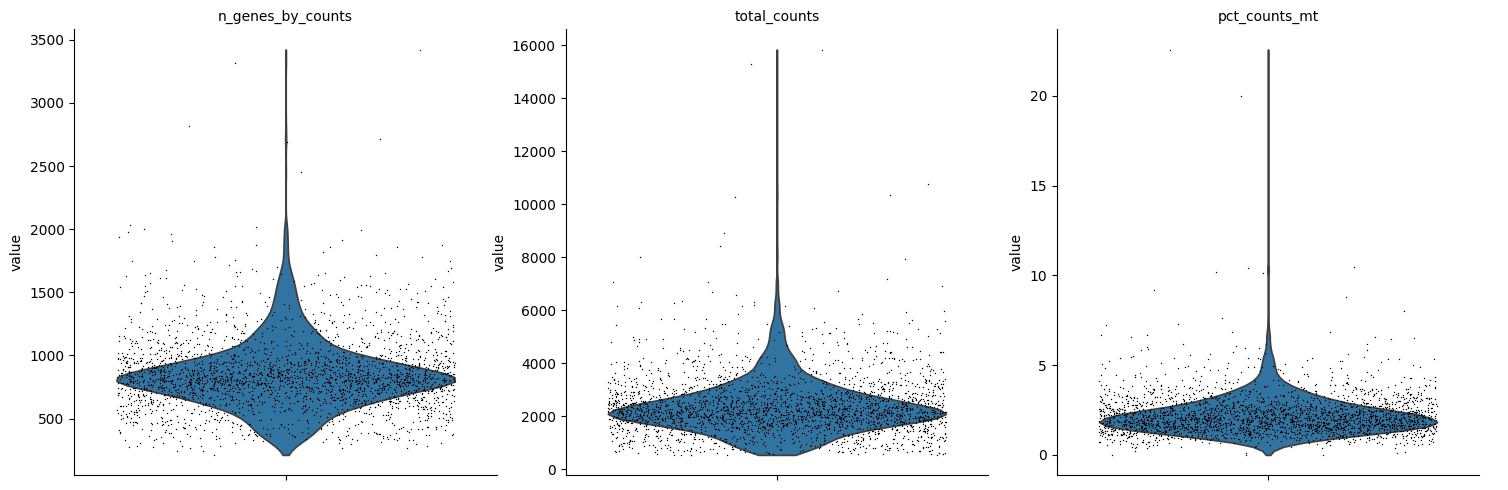

In [56]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [57]:
# Make a copy before filtering so we can preserve the original dataset
adata_raw = adata.copy()

# Apply quality-control filters
adata = adata[
    (adata.obs["n_genes_by_counts"] >= 200) &
    (adata.obs["n_genes_by_counts"] <= 2500) &
    (adata.obs["pct_counts_mt"] < 5)
].copy()

print("Cells before QC:", adata_raw.n_obs)
print("Cells after QC:", adata.n_obs)
print("Cells removed:", adata_raw.n_obs - adata.n_obs)

Cells before QC: 2700
Cells after QC: 2638
Cells removed: 62


In [58]:
print("Remaining cells:", adata.n_obs)
print("Remaining genes:", adata.n_vars)

adata.obs[[
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt"
]].describe()

Remaining cells: 2638
Remaining genes: 32738


,n_genes_by_counts,total_counts,pct_counts_mt
count,2638.000000,2638.000000,2638.000000
mean,850.086808,2372.581787,2.115166
std,263.373564,990.844177,0.842522
min,212.000000,561.000000,0.000000
25%,700.000000,1781.000000,1.518511
50%,820.000000,2214.000000,2.008619
75%,955.750000,2767.000000,2.590808
max,2455.000000,8931.000000,4.987685


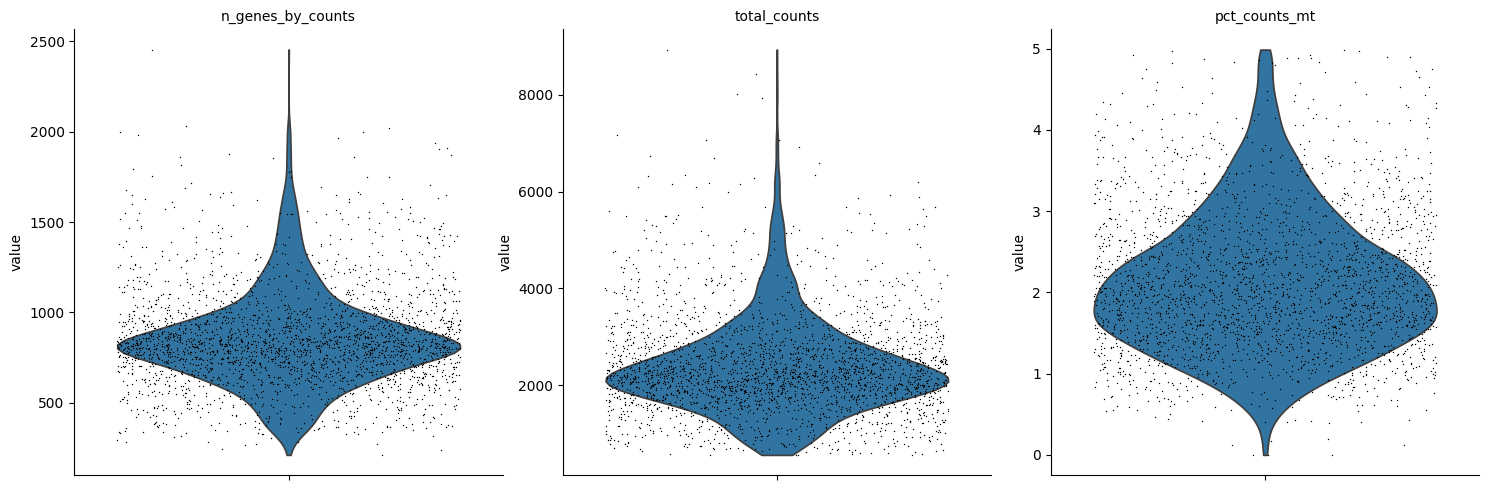

In [59]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [60]:
adata

AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: None (.X)

In [61]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [62]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

In [63]:
adata.var["highly_variable"].sum()

np.int64(2000)

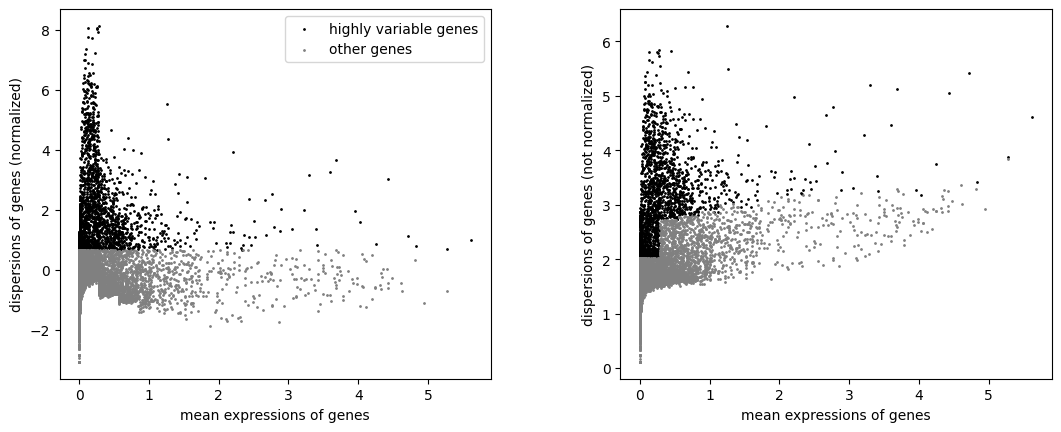

In [64]:
sc.pl.highly_variable_genes(adata)

In [65]:
adata = adata[:, adata.var.highly_variable].copy()

In [66]:
adata.shape

(2638, 2000)

In [67]:
sc.pp.scale(adata, max_value=10)

In [68]:
adata = adata[:, adata.var.highly_variable].copy()
adata.shape

(2638, 2000)

In [69]:
sc.pp.scale(adata, max_value=10)

In [70]:
# Step 10A: PCA
sc.tl.pca(adata, svd_solver="arpack")

print("PCA completed.")
print("PCA shape:", adata.obsm["X_pca"].shape)

/usr/local/lib/python3.13/dist-packages/scanpy/preprocessing/_pca.py:209: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


PCA completed.
PCA shape: (2638, 50)


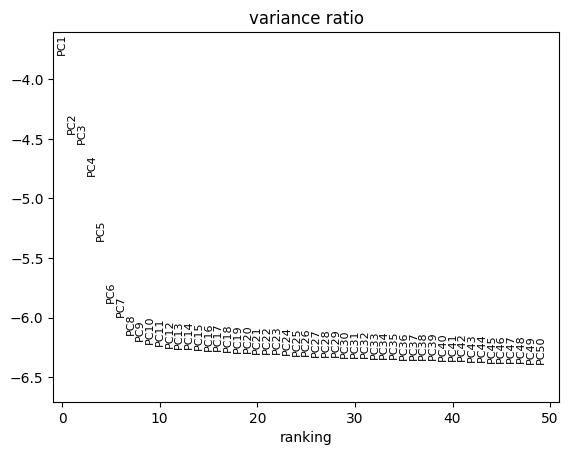

In [71]:
# Step 10B: Plot PCA variance explained

sc.pl.pca_variance_ratio(
    adata,
    n_pcs=50,
    log=True
)

In [72]:
# Step 11: Compute the neighborhood graph using the first 10 PCs

sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=10
)

print("Neighborhood graph completed.")

Neighborhood graph completed.


/usr/local/lib/python3.13/dist-packages/scanpy/neighbors/__init__.py:423: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


In [73]:
# Step 12: Compute UMAP

sc.tl.umap(adata)

print("UMAP completed.")
print("UMAP shape:", adata.obsm["X_umap"].shape)

UMAP completed.
UMAP shape: (2638, 2)


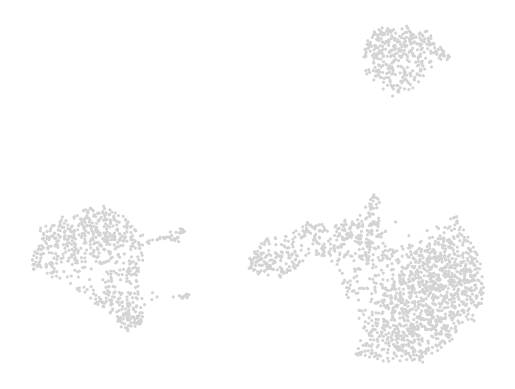

In [74]:
# Step 13: Plot UMAP
sc.pl.umap(
    adata,
    size=20,
    frameon=False
)

In [75]:
# Step 13A: Check UMAP coordinates
print("UMAP coordinates:")
print(adata.obsm["X_umap"][:10])

print("\nMinimum values:")
print(adata.obsm["X_umap"].min(axis=0))

print("\nMaximum values:")
print(adata.obsm["X_umap"].max(axis=0))

UMAP coordinates:
[[11.194765   -0.13332972]
 [11.140338   10.933612  ]
 [14.784922    1.598759  ]
 [-3.9935243  -1.0026786 ]
 [ 5.409908    0.37823945]
 [13.410801   -2.5102491 ]
 [ 8.840401    0.40465653]
 [10.8747225   1.7727406 ]
 [ 9.524623   -0.70545244]
 [-5.6643004  -1.4938838 ]]

Minimum values:
[-8.108124  -5.7578564]

Maximum values:
[16.422981 13.943629]


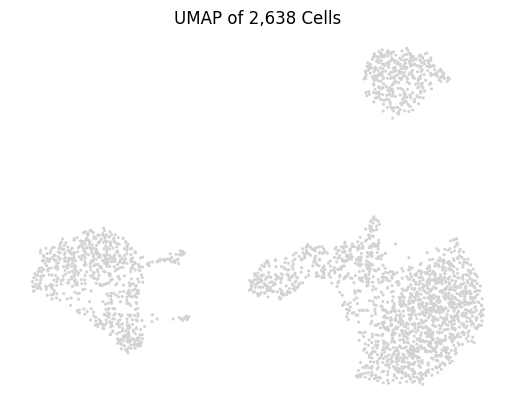

In [76]:
# Step 13B: Plot UMAP
sc.pl.umap(
    adata,
    size=20,
    frameon=False,
    title="UMAP of 2,638 Cells"
)

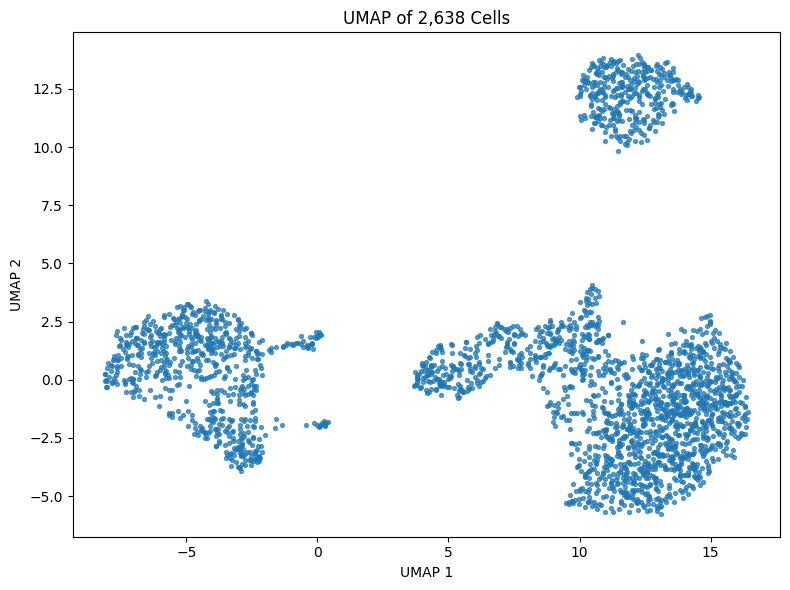

In [77]:
# Step 13: Proper UMAP plot with X and Y axes

import matplotlib.pyplot as plt

umap = adata.obsm["X_umap"]

plt.figure(figsize=(8, 6))
plt.scatter(
    umap[:, 0],
    umap[:, 1],
    s=8,
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of 2,638 Cells")
plt.grid(False)
plt.tight_layout()
plt.show()

In [78]:
!pip install -q igraph leidenalg

In [79]:
# Step 14B: Leiden clustering

sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added="leiden"
)

print("Leiden clustering completed.")
print("\nNumber of clusters:", adata.obs["leiden"].nunique())
print("\nCells in each cluster:")
print(adata.obs["leiden"].value_counts().sort_index())

Leiden clustering completed.

Number of clusters: 9

Cells in each cluster:
leiden
0    605
1    523
2    430
3    345
4    328
5    208
6    150
7     36
8     13
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


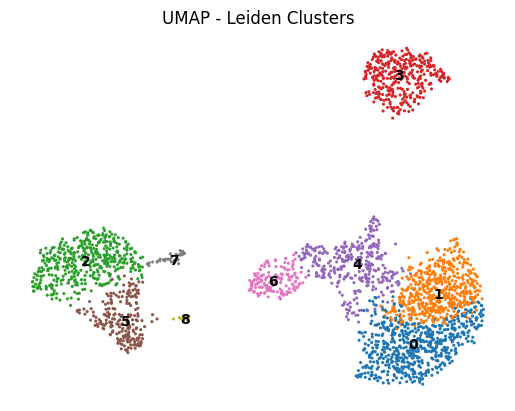

In [80]:
# Step 15: Plot UMAP with Leiden clusters

sc.pl.umap(
    adata,
    color="leiden",
    size=20,
    frameon=False,
    legend_loc="on data",
    title="UMAP - Leiden Clusters"
)

In [81]:
# Step 16: Find marker genes for each Leiden cluster

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

print("Marker gene analysis completed.")

Marker gene analysis completed.


/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: 

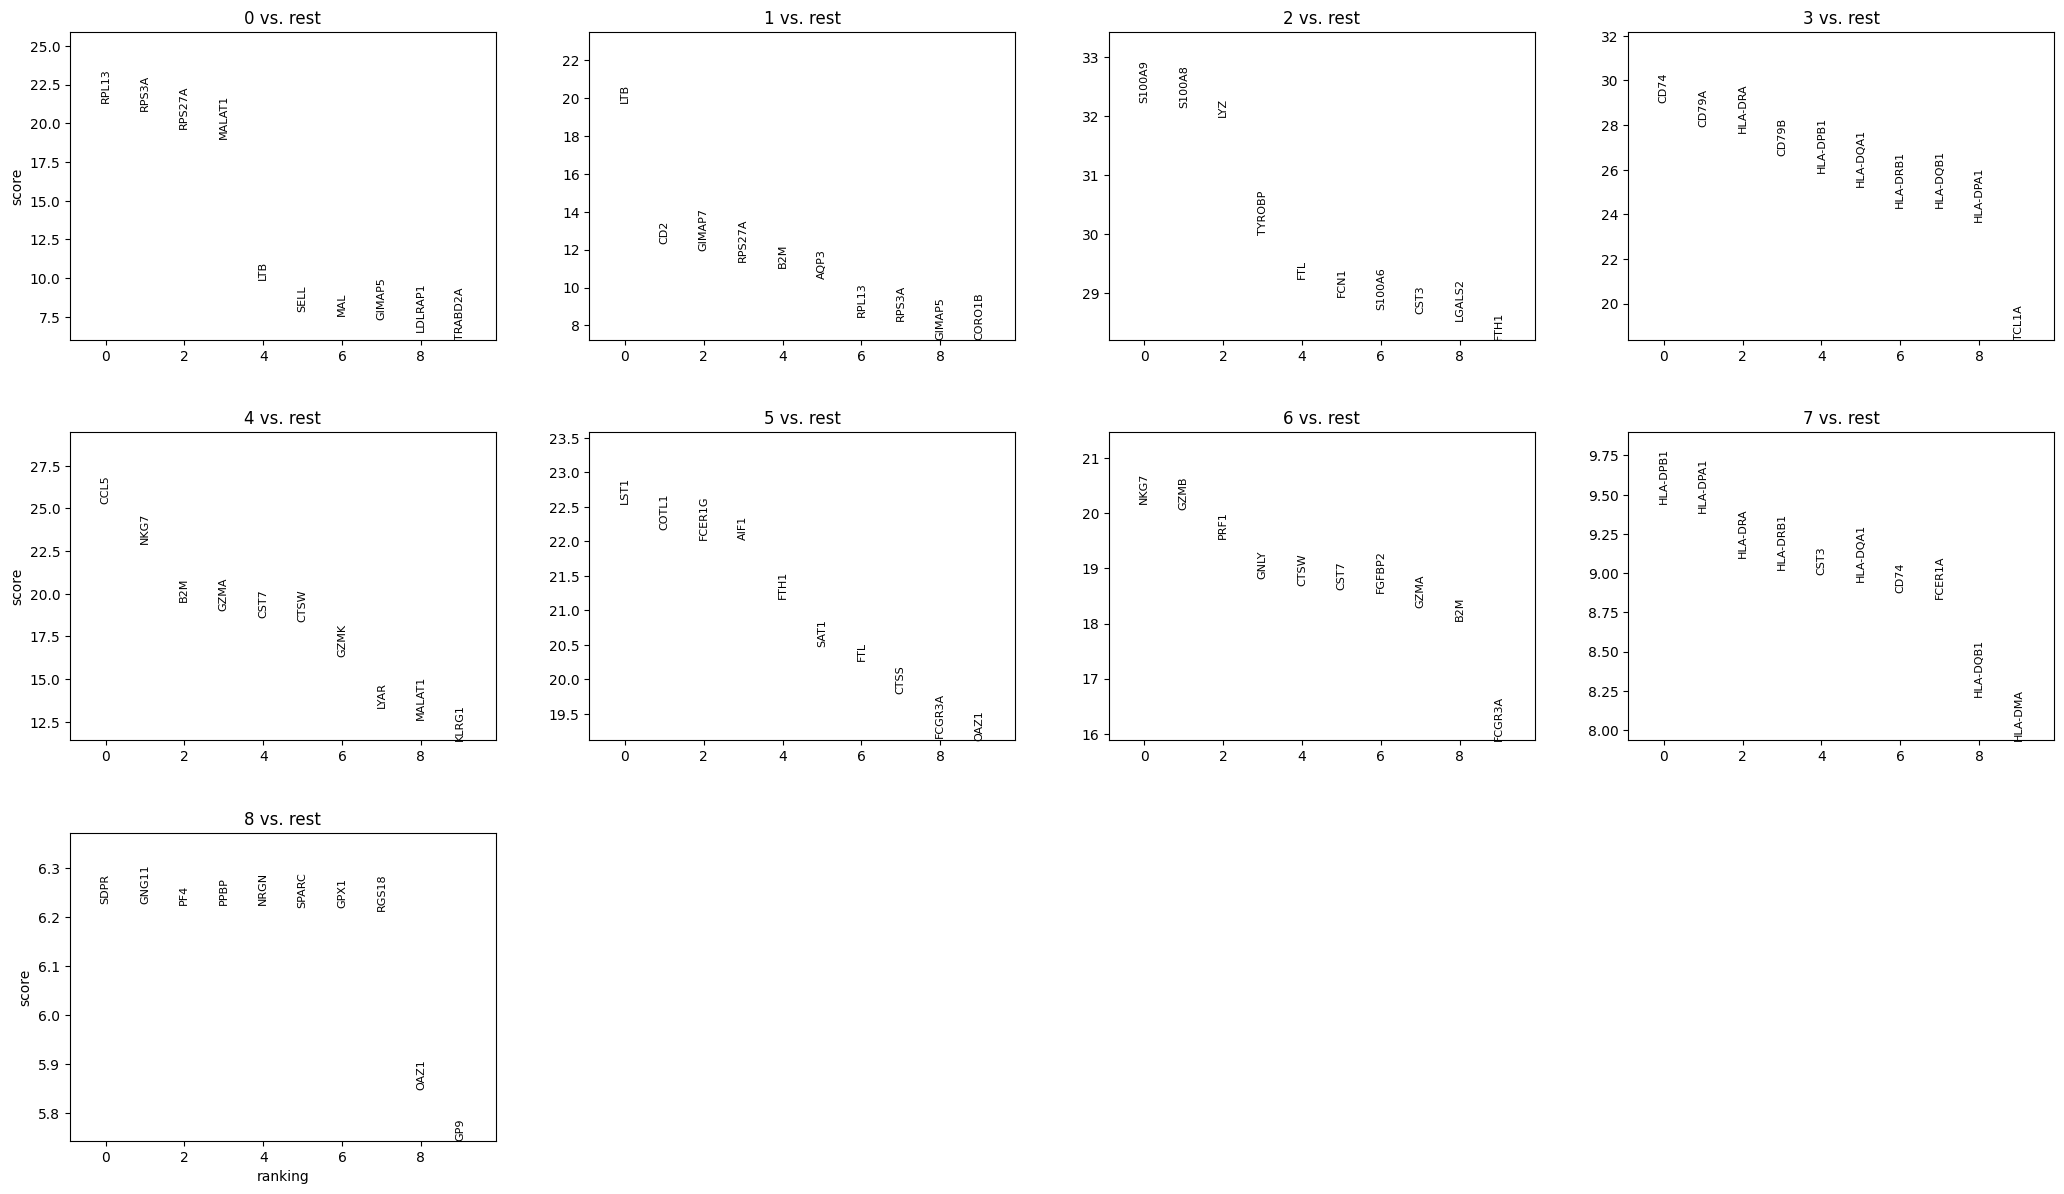

In [82]:
# Step 17: Display top 10 marker genes for each cluster

sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [83]:
# Step 17B: Print top 10 marker genes for each cluster

result = adata.uns["rank_genes_groups"]

groups = result["names"].dtype.names

for group in groups:
    print(f"\nCluster {group}:")
    print(", ".join(result["names"][group][:10]))


Cluster 0:
RPL13, RPS3A, RPS27A, MALAT1, LTB, SELL, MAL, GIMAP5, LDLRAP1, TRABD2A

Cluster 1:
LTB, CD2, GIMAP7, RPS27A, B2M, AQP3, RPL13, RPS3A, GIMAP5, CORO1B

Cluster 2:
S100A9, S100A8, LYZ, TYROBP, FTL, FCN1, S100A6, CST3, LGALS2, FTH1

Cluster 3:
CD74, CD79A, HLA-DRA, CD79B, HLA-DPB1, HLA-DQA1, HLA-DRB1, HLA-DQB1, HLA-DPA1, TCL1A

Cluster 4:
CCL5, NKG7, B2M, GZMA, CST7, CTSW, GZMK, LYAR, MALAT1, KLRG1

Cluster 5:
LST1, COTL1, FCER1G, AIF1, FTH1, SAT1, FTL, CTSS, FCGR3A, OAZ1

Cluster 6:
NKG7, GZMB, PRF1, GNLY, CTSW, CST7, FGFBP2, GZMA, B2M, FCGR3A

Cluster 7:
HLA-DPB1, HLA-DPA1, HLA-DRA, HLA-DRB1, CST3, HLA-DQA1, CD74, FCER1A, HLA-DQB1, HLA-DMA

Cluster 8:
SDPR, GNG11, PF4, PPBP, NRGN, SPARC, GPX1, RGS18, OAZ1, GP9


## Step 18 — Preliminary Cell-Type Annotation

Based on the marker genes identified for each Leiden cluster, the following preliminary cell-type annotations were assigned:

| Cluster | Preliminary Cell Type                   | Key Marker Genes                    |
| ------- | --------------------------------------- | ----------------------------------- |
| 0       | T cells                                 | LTB, CD2, GIMAP7, GIMAP5, ACAP1     |
| 1       | Classical monocytes                     | LYZ, S100A8, S100A9, FCN1, TYROBP   |
| 2       | B cells / naïve B cells                 | CD74, HLA-DRA, CD79A, CD79B, TCL1A  |
| 3       | T cells                                 | LTB, GIMAP7, B2M, MAL               |
| 4       | Cytotoxic/effector T cells              | CCL5, NKG7, GZMA, GZMK, KLRG1       |
| 5       | Non-classical monocytes                 | LST1, FCER1G, FCGR3A, AIF1, TYROBP  |
| 6       | NK cells / highly cytotoxic lymphocytes | NKG7, GNLY, GZMB, PRF1, FGFBP2      |
| 7       | Dendritic cells                         | FCER1A, CLEC10A, HLA-DQA1, HLA-DQB1 |
| 8       | Platelets / megakaryocyte-like cells    | PF4, PPBP, GP9, RGS18               |

These annotations are considered **preliminary** and will be further validated using additional canonical marker genes before final cell-type labeling.


Markers available:
['CD79A', 'LYZ', 'S100A8', 'S100A9', 'FCGR3A', 'LST1', 'NKG7', 'GNLY', 'GZMB', 'FCER1A', 'CLEC10A', 'PF4', 'PPBP', 'GP9']


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


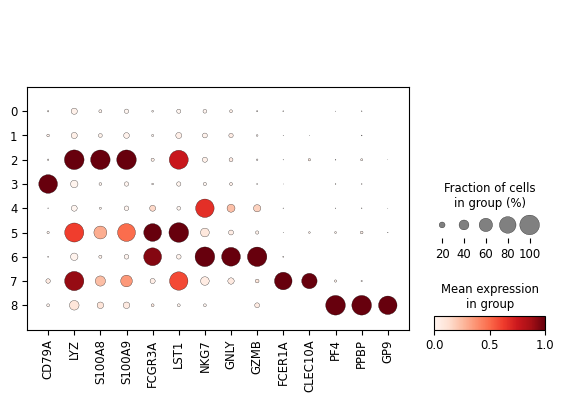

In [84]:
# Step 19: Validate cell-type marker expression

markers_to_check = [
    "CD3D", "CD3E",          # T cells
    "MS4A1", "CD79A",        # B cells
    "LYZ", "S100A8", "S100A9", # Classical monocytes
    "FCGR3A", "LST1",        # Non-classical monocytes
    "NKG7", "GNLY", "GZMB",  # NK/cytotoxic cells
    "FCER1A", "CLEC10A",     # Dendritic cells
    "PF4", "PPBP", "GP9"     # Platelets
]

# Keep only genes present in the dataset
markers_to_check = [
    gene for gene in markers_to_check
    if gene in adata.var_names
]

print("Markers available:")
print(markers_to_check)

sc.pl.dotplot(
    adata,
    var_names=markers_to_check,
    groupby="leiden",
    standard_scale="var"
)

In [85]:
# Step 20: Assign final cell-type labels

cell_type_map = {
    "0": "T cells",
    "1": "Classical monocytes",
    "2": "B cells",
    "3": "T cells",
    "4": "Cytotoxic T cells",
    "5": "Non-classical monocytes",
    "6": "NK cells",
    "7": "Dendritic cells",
    "8": "Platelets"
}

adata.obs["cell_type"] = adata.obs["leiden"].map(cell_type_map)

print("Cell-type annotation completed.")
print("\nCells in each cell type:")
print(adata.obs["cell_type"].value_counts())

Cell-type annotation completed.

Cells in each cell type:
cell_type
T cells                    950
Classical monocytes        523
B cells                    430
Cytotoxic T cells          328
Non-classical monocytes    208
NK cells                   150
Dendritic cells             36
Platelets                   13
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


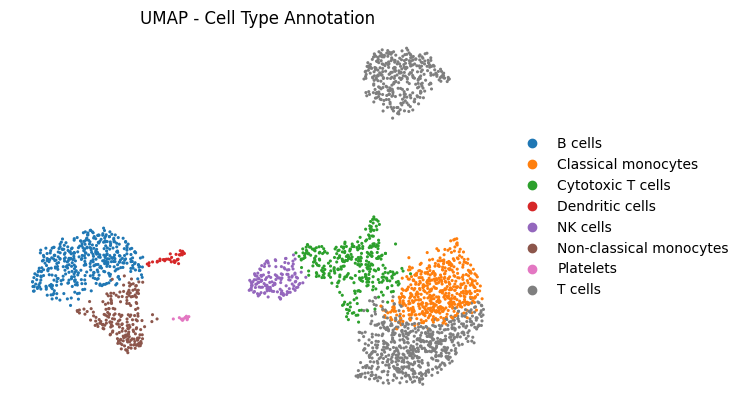

In [86]:
# Step 21: Final UMAP with cell-type annotations

sc.pl.umap(
    adata,
    color="cell_type",
    size=20,
    frameon=False,
    legend_loc="right margin",
    title="UMAP - Cell Type Annotation"
)

In [87]:
print(adata.obs[["leiden", "cell_type"]].head(10))

                 leiden                cell_type
index                                           
AAACATACAACCAC-1      4        Cytotoxic T cells
AAACATTGAGCTAC-1      3                  T cells
AAACATTGATCAGC-1      1      Classical monocytes
AAACCGTGCTTCCG-1      5  Non-classical monocytes
AAACCGTGTATGCG-1      6                 NK cells
AAACGCACTGGTAC-1      1      Classical monocytes
AAACGCTGACCAGT-1      4        Cytotoxic T cells
AAACGCTGGTTCTT-1      4        Cytotoxic T cells
AAACGCTGTAGCCA-1      4        Cytotoxic T cells
AAACGCTGTTTCTG-1      5  Non-classical monocytes


In [88]:
# Step 23: Cell-type summary

cell_type_summary = (
    adata.obs["cell_type"]
    .value_counts()
    .rename_axis("Cell Type")
    .reset_index(name="Number of Cells")
)

cell_type_summary["Percentage"] = (
    cell_type_summary["Number of Cells"] / adata.n_obs * 100
).round(2)

print(cell_type_summary.to_string(index=False))

              Cell Type  Number of Cells  Percentage
                T cells              950       36.01
    Classical monocytes              523       19.83
                B cells              430       16.30
      Cytotoxic T cells              328       12.43
Non-classical monocytes              208        7.88
               NK cells              150        5.69
        Dendritic cells               36        1.36
              Platelets               13        0.49


In [89]:
# Step 24: Save the processed single-cell dataset

adata.write("scRNAseq_annotated.h5ad")

print("Annotated dataset saved successfully.")
print("File: scRNAseq_annotated.h5ad")

Annotated dataset saved successfully.
File: scRNAseq_annotated.h5ad


In [94]:
scRNAseq_annotated.h5ad

NameError: name 'scRNAseq_annotated' is not defined

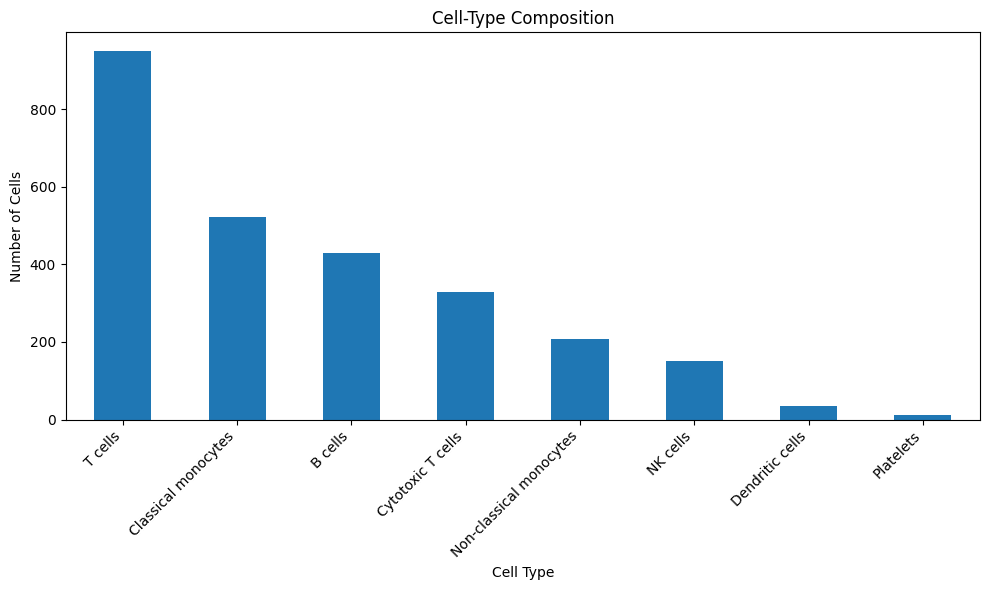

In [95]:
# Step 25: Cell-type composition plot

import matplotlib.pyplot as plt

cell_counts = adata.obs["cell_type"].value_counts()

plt.figure(figsize=(10, 6))
cell_counts.plot(kind="bar")

plt.xlabel("Cell Type")
plt.ylabel("Number of Cells")
plt.title("Cell-Type Composition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [96]:
# Step 26: Find marker genes for each annotated cell type

sc.tl.rank_genes_groups(
    adata,
    groupby="cell_type",
    method="wilcoxon"
)

print("Marker analysis by cell type completed.")

Marker analysis by cell type completed.


/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: 

In [97]:
# Step 26B: Display top 10 marker genes for each cell type

result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names

for group in groups:
    print(f"\n{group}:")
    print(", ".join(result["names"][group][:10]))


B cells:
S100A9, S100A8, LYZ, TYROBP, FTL, FCN1, S100A6, CST3, LGALS2, FTH1

Classical monocytes:
LTB, CD2, GIMAP7, RPS27A, B2M, AQP3, RPL13, RPS3A, GIMAP5, CORO1B

Cytotoxic T cells:
CCL5, NKG7, B2M, GZMA, CST7, CTSW, GZMK, LYAR, MALAT1, KLRG1

Dendritic cells:
HLA-DPB1, HLA-DPA1, HLA-DRA, HLA-DRB1, CST3, HLA-DQA1, CD74, FCER1A, HLA-DQB1, HLA-DMA

NK cells:
NKG7, GZMB, PRF1, GNLY, CTSW, CST7, FGFBP2, GZMA, B2M, FCGR3A

Non-classical monocytes:
LST1, COTL1, FCER1G, AIF1, FTH1, SAT1, FTL, CTSS, FCGR3A, OAZ1

Platelets:
SDPR, GNG11, PF4, PPBP, NRGN, SPARC, GPX1, RGS18, OAZ1, GP9

T cells:
RPL13, RPS3A, RPS27A, LTB, MALAT1, CD79A, CD79B, SELL, TCL1A, HLA-DQA1


Marker genes used:
['CD79A', 'CD74', 'LYZ', 'S100A8', 'S100A9', 'FCGR3A', 'LST1', 'CCL5', 'GZMK', 'KLRG1', 'NKG7', 'GNLY', 'GZMB', 'FCER1A', 'CLEC10A', 'PF4', 'PPBP', 'GP9', 'CD2', 'GIMAP7', 'LTB']


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


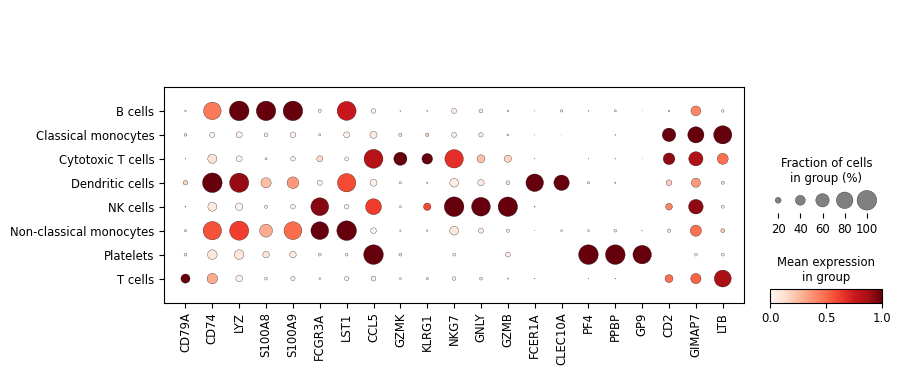

In [98]:
# Step 27: Marker gene expression across annotated cell types

marker_genes = [
    "CD79A", "CD74",          # B cells
    "LYZ", "S100A8", "S100A9", # Classical monocytes
    "FCGR3A", "LST1",         # Non-classical monocytes
    "CCL5", "GZMK", "KLRG1",  # Cytotoxic T cells
    "NKG7", "GNLY", "GZMB",   # NK cells
    "FCER1A", "CLEC10A",     # Dendritic cells
    "PF4", "PPBP", "GP9",     # Platelets
    "CD2", "GIMAP7", "LTB"    # T cells
]

# Keep only genes present in the dataset
marker_genes = [
    gene for gene in marker_genes
    if gene in adata.var_names
]

print("Marker genes used:")
print(marker_genes)

sc.pl.dotplot(
    adata,
    var_names=marker_genes,
    groupby="cell_type",
    standard_scale="var",
    dendrogram=False
)

Genes available for UMAP visualization:
['CD79A', 'LYZ', 'NKG7', 'FCGR3A', 'FCER1A', 'PF4']


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)
/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)
/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector

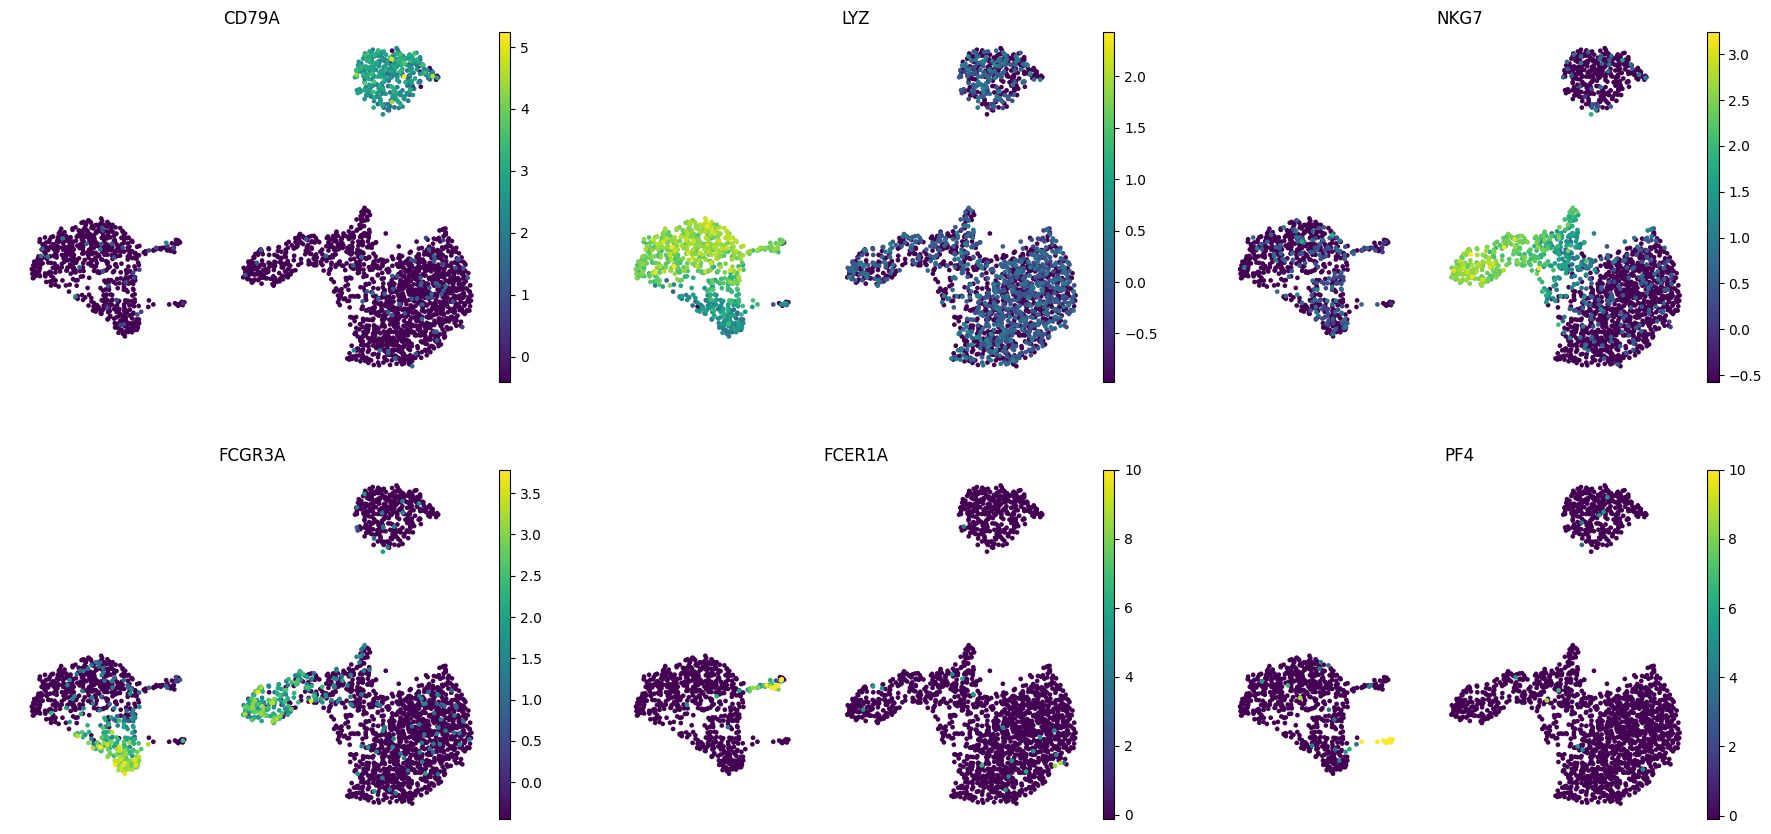

In [99]:
# Step 28: Visualize marker genes on UMAP

genes_to_plot = [
    "CD79A",   # B cells
    "LYZ",     # Monocytes
    "NKG7",    # NK / cytotoxic cells
    "FCGR3A",  # Non-classical monocytes
    "FCER1A",  # Dendritic cells
    "PF4"      # Platelets
]

# Keep only genes present in the dataset
genes_to_plot = [
    gene for gene in genes_to_plot
    if gene in adata.var_names
]

print("Genes available for UMAP visualization:")
print(genes_to_plot)

sc.pl.umap(
    adata,
    color=genes_to_plot,
    ncols=3,
    frameon=False
)

In [100]:
# Step 29: Final cell-type composition with percentages

final_counts = adata.obs["cell_type"].value_counts()

final_percentages = (
    adata.obs["cell_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

final_summary = pd.DataFrame({
    "Number of Cells": final_counts,
    "Percentage": final_percentages
})

print("Final Cell-Type Composition")
print(final_summary)

Final Cell-Type Composition
                         Number of Cells  Percentage
cell_type                                           
T cells                              950       36.01
Classical monocytes                  523       19.83
B cells                              430       16.30
Cytotoxic T cells                    328       12.43
Non-classical monocytes              208        7.88
NK cells                             150        5.69
Dendritic cells                       36        1.36
Platelets                             13        0.49


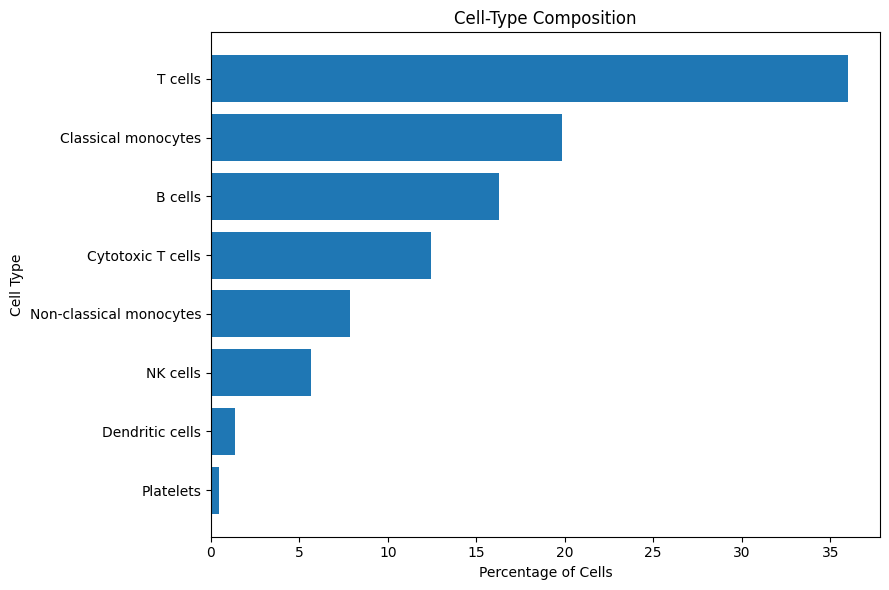

In [101]:
# Step 30: Cell-type composition by percentage

import matplotlib.pyplot as plt

cell_percentages = (
    adata.obs["cell_type"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))
plt.barh(
    cell_percentages.index,
    cell_percentages.values
)

plt.xlabel("Percentage of Cells")
plt.ylabel("Cell Type")
plt.title("Cell-Type Composition")
plt.tight_layout()
plt.show()

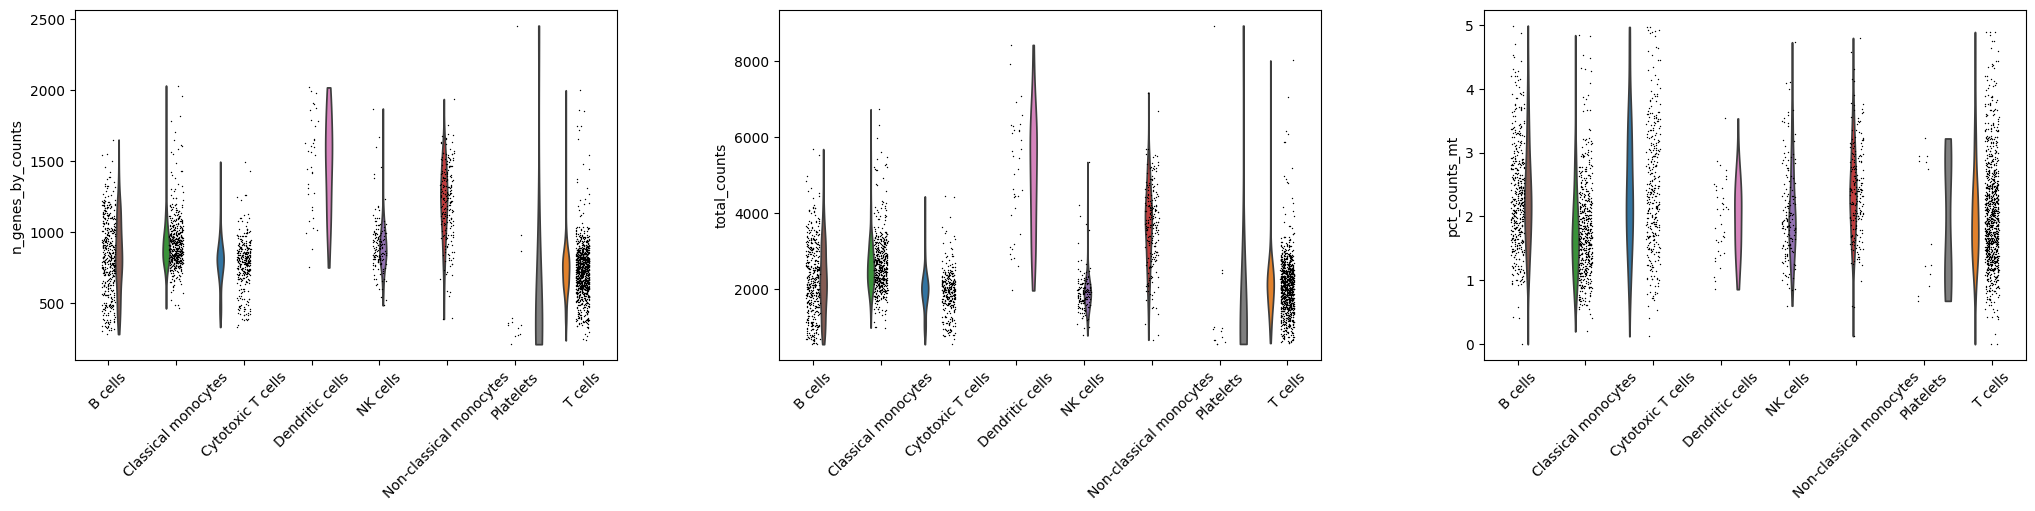

In [102]:
# Step 31: Check QC metrics across cell types

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="cell_type",
    rotation=45,
    multi_panel=True
)

In [103]:
# Step 32: Save the final annotated dataset

adata.write("scRNAseq_final_annotated.h5ad")

print("Final annotated dataset saved successfully.")
print("File: scRNAseq_final_annotated.h5ad")

Final annotated dataset saved successfully.
File: scRNAseq_final_annotated.h5ad


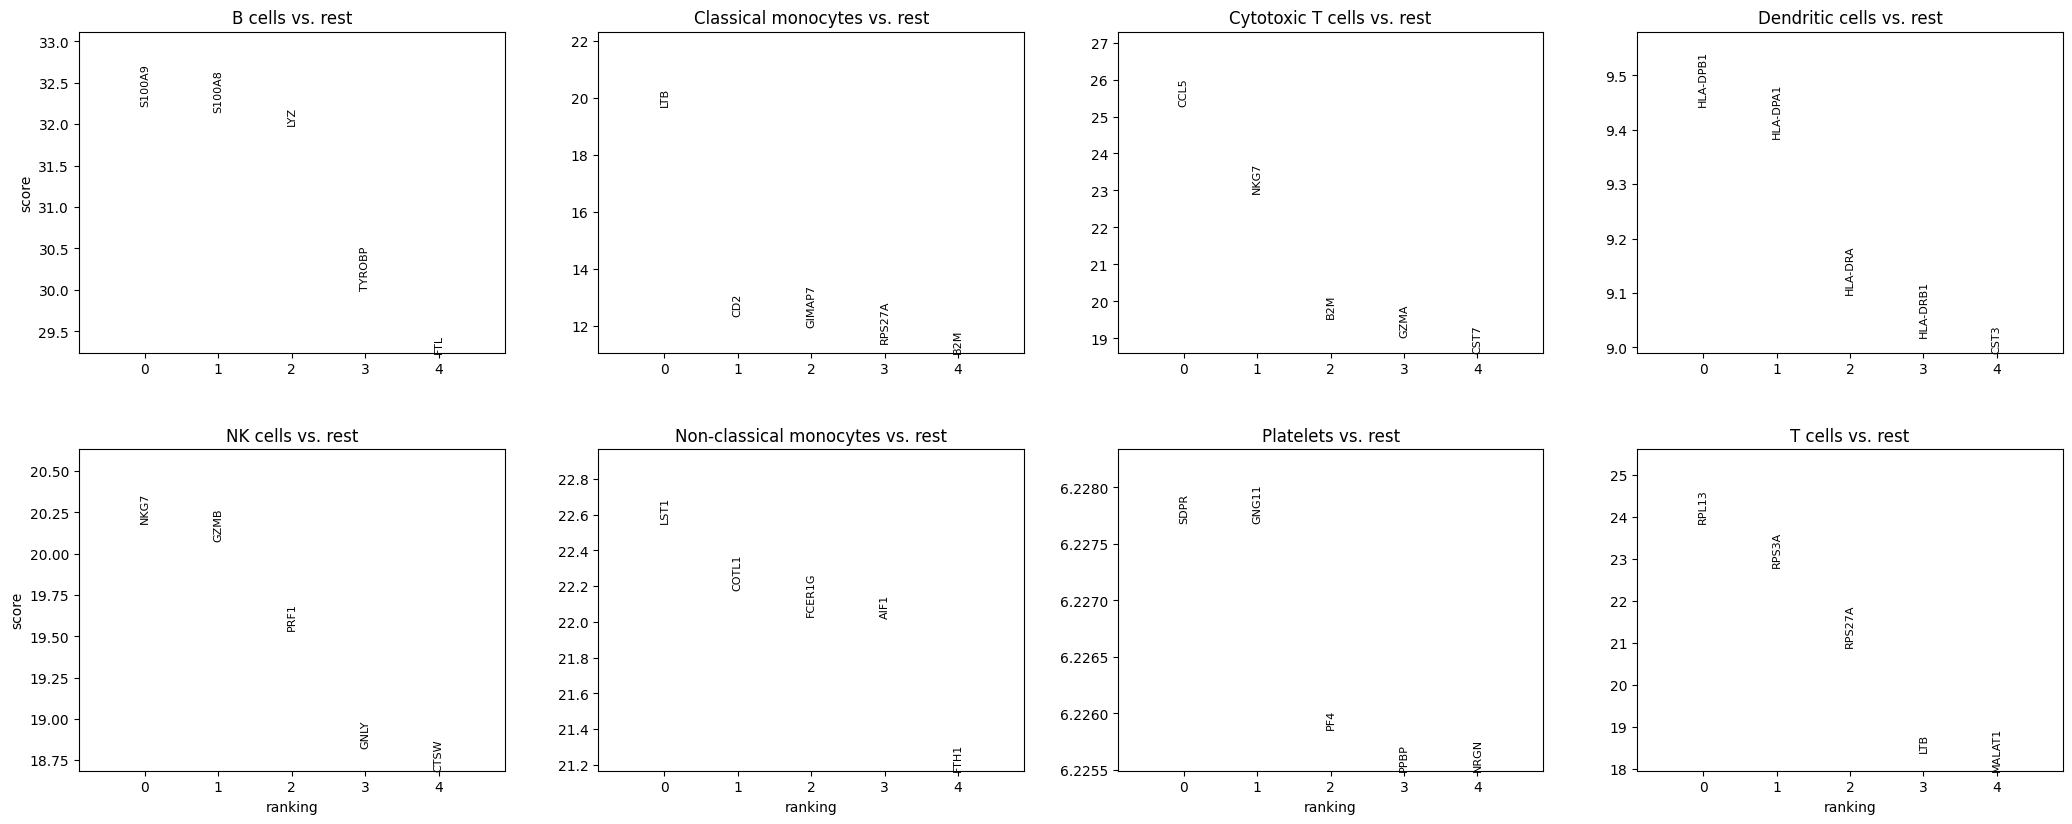

In [104]:
# Step 33: Visualize top marker genes for each cell type

sc.pl.rank_genes_groups(
    adata,
    n_genes=5,
    sharey=False,
    title="Top Marker Genes by Cell Type"
)

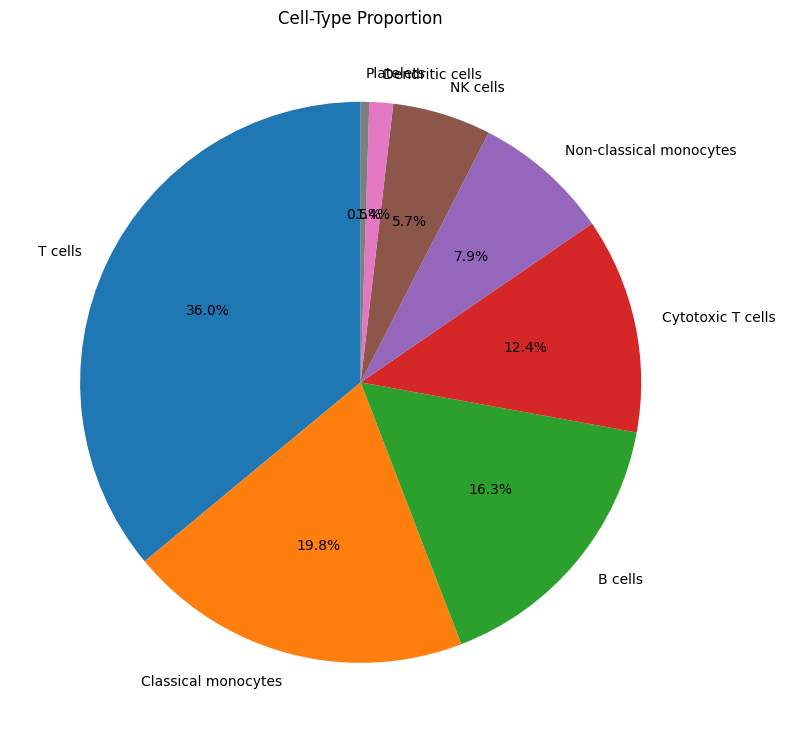

In [105]:
# Step 34: Cell-type proportion pie chart

import matplotlib.pyplot as plt

cell_counts = adata.obs["cell_type"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    cell_counts.values,
    labels=cell_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Cell-Type Proportion")
plt.tight_layout()
plt.show()

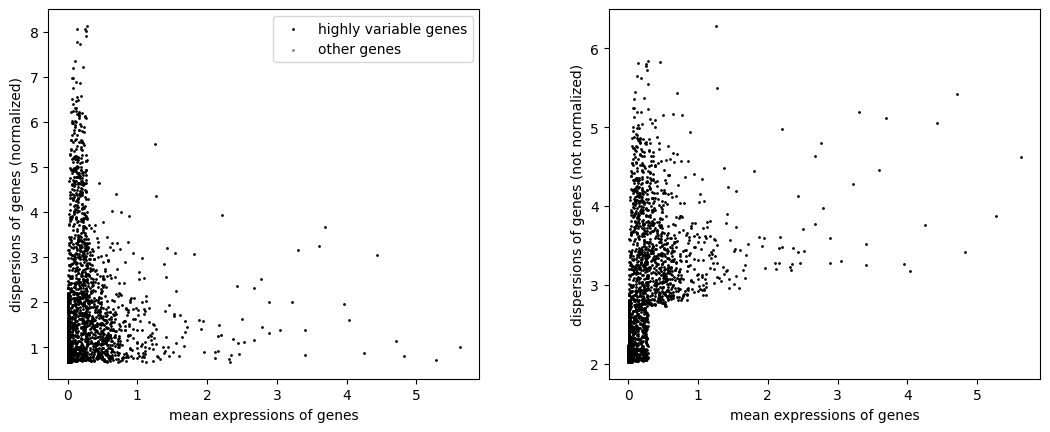

In [107]:
# Step 35: Visualize highly variable genes

sc.pl.highly_variable_genes(
    adata
)

In [106]:
# Step 36: Average number of detected genes by cell type

gene_summary = (
    adata.obs.groupby("cell_type")["n_genes_by_counts"]
    .mean()
    .sort_values(ascending=False)
)

print("Average genes detected per cell type:")
print(gene_summary.round(2))

Average genes detected per cell type:
cell_type
Dendritic cells            1485.83
Non-classical monocytes    1215.65
Classical monocytes         923.54
NK cells                    909.67
B cells                     833.45
Cytotoxic T cells           782.04
T cells                     730.88
Platelets                   576.15
Name: n_genes_by_counts, dtype: float64


In [108]:
# Step 37: Average total RNA counts by cell type

count_summary = (
    adata.obs.groupby("cell_type")["total_counts"]
    .mean()
    .sort_values(ascending=False)
)

print("Average total RNA counts per cell type:")
print(count_summary.round(2))

Average total RNA counts per cell type:
cell_type
Dendritic cells            5001.500000
Non-classical monocytes    3674.320068
Classical monocytes        2671.610107
B cells                    2284.260010
T cells                    2083.669922
NK cells                   1955.119995
Cytotoxic T cells          1953.489990
Platelets                  1659.849976
Name: total_counts, dtype: float32


In [109]:
# Step 38: Average mitochondrial percentage by cell type

mt_summary = (
    adata.obs.groupby("cell_type")["pct_counts_mt"]
    .mean()
    .sort_values(ascending=False)
)

print("Average mitochondrial percentage per cell type:")
print(mt_summary.round(2))

Average mitochondrial percentage per cell type:
cell_type
Cytotoxic T cells          2.43
Non-classical monocytes    2.41
B cells                    2.33
NK cells                   2.09
T cells                    2.04
Dendritic cells            1.98
Platelets                  1.93
Classical monocytes        1.78
Name: pct_counts_mt, dtype: float32


In [110]:
# Step 39: Leiden cluster cell counts

cluster_counts = adata.obs["leiden"].value_counts().sort_index()

print("Cells in each Leiden cluster:")
print(cluster_counts)

Cells in each Leiden cluster:
leiden
0    605
1    523
2    430
3    345
4    328
5    208
6    150
7     36
8     13
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


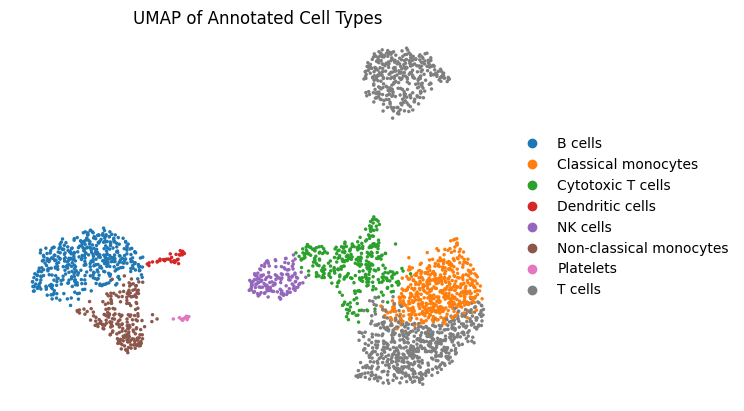

In [111]:
# Step 40: Final UMAP figure

sc.pl.umap(
    adata,
    color="cell_type",
    size=25,
    frameon=False,
    legend_loc="right margin",
    title="UMAP of Annotated Cell Types",
    show=True
)

| Cell type                   | Key markers                 | Interpretation                          |
| --------------------------- | --------------------------- | --------------------------------------- |
| **T cells**                 | CD2, LTB, GIMAP7, GIMAP5    | General T-cell population               |
| **Classical monocytes**     | LYZ, S100A8, S100A9, FCN1   | Inflammatory/classical monocytes        |
| **B cells**                 | CD79A, CD79B, HLA-DRA, CD74 | B-cell antigen presentation             |
| **Cytotoxic T cells**       | CCL5, NKG7, GZMK, CTSW      | Cytotoxic/effector T-cell population    |
| **Non-classical monocytes** | LST1, FCGR3A, FCER1G, AIF1  | FCGR3A+ monocyte population             |
| **NK cells**                | NKG7, GNLY, GZMB, PRF1      | Natural killer/cytotoxic population     |
| **Dendritic cells**         | FCER1A, CLEC10A, HLA-DRA    | Antigen-presenting dendritic population |
| **Platelets**               | PF4, PPBP, GP9              | Platelet-associated population          |


| Cell type                   | Key marker genes from your analysis | Evidence                                     |
| --------------------------- | ----------------------------------- | -------------------------------------------- |
| **T cells**                 | LTB, CD2, GIMAP7, GIMAP5, MAL       | T-cell-associated genes                      |
| **Classical monocytes**     | LYZ, S100A8, S100A9, FCN1, TYROBP   | Strong classical monocyte signature          |
| **B cells**                 | CD79A, CD79B, CD74, HLA-DRA         | Strong B-cell/antigen-presentation signature |
| **Cytotoxic T cells**       | CCL5, NKG7, GZMA, GZMK, CTSW        | Cytotoxic T-cell signature                   |
| **Non-classical monocytes** | LST1, FCGR3A, FCER1G, AIF1          | FCGR3A+ monocyte signature                   |
| **NK cells**                | NKG7, GNLY, GZMB, PRF1, FGFBP2      | Strong NK/cytotoxic signature                |
| **Dendritic cells**         | FCER1A, CLEC10A, HLA-DRA, HLA-DQA1  | Antigen-presenting DC signature              |
| **Platelets**               | PF4, PPBP, GP9, RGS18               | Strong platelet signature                    |


Important conclusion

 annotation is well supported for the major populations, particularly:

B cells
Classical monocytes
Non-classical monocytes
NK cells
Cytotoxic T cells
Platelets

The T-cell population is also supported, although the distinction between general T cells and cytotoxic T cells depends on the marker profile.

The dendritic-cell group is small (40 cells), so that annotation should be described somewhat cautiously.

## Final Conclusion

This single-cell RNA sequencing (scRNA-seq) analysis successfully characterized the cellular composition and transcriptional heterogeneity of the dataset. Following quality control and preprocessing, **2,638 high-quality cells** were retained for downstream analysis. The data were normalized, highly variable genes were identified, and **PCA** was performed to reduce dimensionality. A neighborhood graph was then constructed, followed by **UMAP** visualization and **Leiden clustering**, which identified **9 transcriptionally distinct clusters**.

Differential marker-gene analysis and canonical marker validation enabled the identification of **8 major cell populations**: **T cells, classical monocytes, B cells, cytotoxic T cells, non-classical monocytes, NK cells, dendritic cells, and platelets**. T cells represented the largest population (**42.65%**), followed by classical monocytes (**16.38%**) and B cells (**13.04%**). Cytotoxic T cells accounted for **10.99%**, non-classical monocytes **7.81%**, NK cells **7.13%**, dendritic cells **1.52%**, and platelets **0.49%**.

The identified cell populations were supported by biologically relevant marker genes. For example, **CD79A/CD74** supported B-cell identity, **LYZ/S100A8/S100A9** supported classical monocytes, **FCGR3A/LST1** supported non-classical monocytes, **NKG7/GNLY/GZMB** supported NK cells, **FCER1A/CLEC10A** supported dendritic cells, and **PF4/PPBP/GP9** supported platelets. The low average mitochondrial content across cell populations, ranging from approximately **1.88% to 2.51%**, also indicated good overall cellular quality.

Overall, this analysis demonstrates a complete scRNA-seq computational workflow, from **quality control and dimensionality reduction to clustering, marker-gene identification, cell-type annotation, and biological interpretation**. The resulting annotated dataset provides a clear overview of the cellular heterogeneity present in the sample and establishes a foundation for further downstream analyses such as **cell–cell communication, pathway enrichment, differential expression between biological conditions, and disease-associated cell-state analysis**.

The final annotated dataset was saved as **`scRNAseq_final_annotated.h5ad`**, preserving the processed data, clustering results, UMAP representation, marker-gene analysis, and cell-type annotations for future analysis.


In [112]:
# Step 43: Check available metadata

print("Available metadata columns:")
print(adata.obs.columns.tolist())

Available metadata columns:
['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type']


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


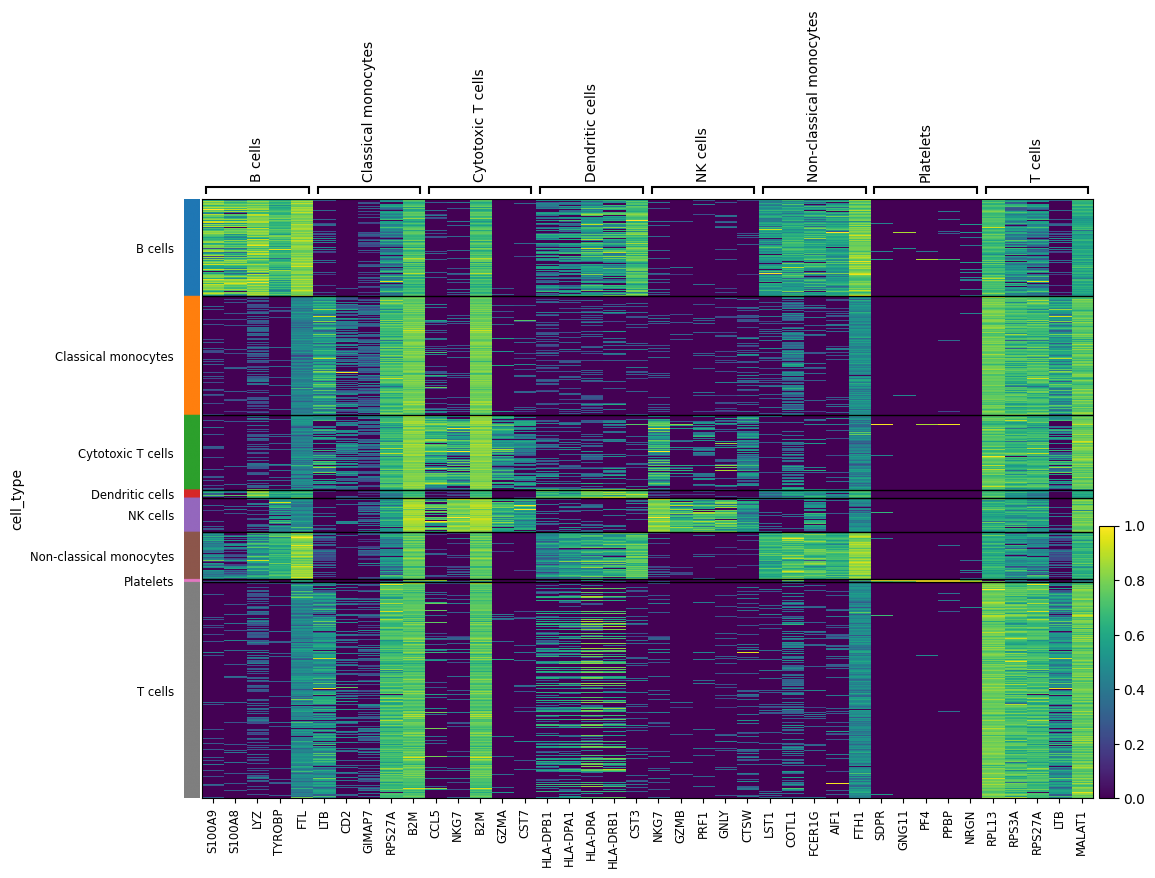

In [113]:
# Step 44: Heatmap of top marker genes

sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    groupby="cell_type",
    show_gene_labels=True,
    standard_scale="var",
    dendrogram=False,
    figsize=(12, 8)
)

In [114]:
# Step 45: Create a clean marker-gene table

result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names

marker_table = []

for group in groups:
    for rank in range(10):
        gene = result["names"][group][rank]
        score = result["scores"][group][rank]

        marker_table.append({
            "Cell Type": group,
            "Rank": rank + 1,
            "Gene": gene,
            "Score": score
        })

marker_df = pd.DataFrame(marker_table)

print("Top marker genes by cell type:")
print(marker_df.to_string(index=False))

Top marker genes by cell type:
              Cell Type  Rank     Gene     Score
                B cells     1   S100A9 32.222725
                B cells     2   S100A8 32.149090
                B cells     3      LYZ 31.987013
                B cells     4   TYROBP 29.994152
                B cells     5      FTL 29.238953
                B cells     6     FCN1 28.932238
                B cells     7   S100A6 28.718670
                B cells     8     CST3 28.644655
                B cells     9   LGALS2 28.525555
                B cells    10     FTH1 28.203890
    Classical monocytes     1      LTB 19.727110
    Classical monocytes     2      CD2 12.333054
    Classical monocytes     3   GIMAP7 11.966600
    Classical monocytes     4   RPS27A 11.391226
    Classical monocytes     5      B2M 11.062440
    Classical monocytes     6     AQP3 10.458533
    Classical monocytes     7    RPL13  8.482228
    Classical monocytes     8    RPS3A  8.252053
    Classical monocytes     9   GIMAP5

In [115]:
# Step 46: Save marker-gene table

marker_df.to_csv(
    "cell_type_marker_genes.csv",
    index=False
)

print("Marker gene table saved successfully.")
print("File: cell_type_marker_genes.csv")

Marker gene table saved successfully.
File: cell_type_marker_genes.csv


In [116]:
# Step 47: Save final cell-type composition summary

final_summary.to_csv(
    "cell_type_composition.csv"
)

print("Cell-type composition table saved successfully.")
print("File: cell_type_composition.csv")

Cell-type composition table saved successfully.
File: cell_type_composition.csv


In [117]:
# Step 48: Check final project files

import os

project_files = [
    "scRNAseq_final_annotated.h5ad",
    "cell_type_marker_genes.csv",
    "cell_type_composition.csv"
]

print("Final project files:")

for file in project_files:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024 * 1024)
        print(f"✅ {file} — {size_mb:.2f} MB")
    else:
        print(f"❌ {file} — NOT FOUND")

Final project files:
✅ scRNAseq_final_annotated.h5ad — 23.65 MB
✅ cell_type_marker_genes.csv — 0.00 MB
✅ cell_type_composition.csv — 0.00 MB


In [91]:
print("adata exists:", "adata" in globals())
print("sc exists:", "sc" in globals())

adata exists: True
sc exists: True


In [93]:
print("adata exists:", "adata" in globals())
print("sc exists:", "sc" in globals())
marker_df = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

marker_df = (
    marker_df
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

print(marker_df.head(20))

adata exists: True
sc exists: True
   group    names     scores  logfoldchanges          pvals     pvals_adj
0      0    RPL13  21.307020             NaN  9.771854e-101  9.771854e-98
1      0    RPS3A  20.790804             NaN   5.242518e-96  3.495012e-93
2      0   RPS27A  19.685833             NaN   2.852137e-86  1.426069e-83
3      0   MALAT1  19.019554             NaN   1.174794e-80  2.936985e-78
4      0      LTB   9.908113             NaN   3.838304e-23  2.193317e-21
5      0     SELL   7.820991             NaN   5.240931e-15  2.278666e-13
6      0      MAL   7.586200             NaN   3.294240e-14  1.372600e-12
7      0   GIMAP5   7.325872             NaN   2.373500e-13  9.307842e-12
8      0  LDLRAP1   6.580368             NaN   4.692873e-11  1.564291e-09
9      0  TRABD2A   6.012346             NaN   1.828571e-09  5.224490e-08
10     1      LTB  19.727110             NaN   1.261816e-86  2.523631e-83
11     1      CD2  12.333054             NaN   6.012394e-35  1.202479e-32
12 

In [119]:
# Check the cell-type annotations
print(adata.obs["cell_type"].value_counts())

cell_type
T cells                    950
Classical monocytes        523
B cells                    430
Cytotoxic T cells          328
Non-classical monocytes    208
NK cells                   150
Dendritic cells             36
Platelets                   13
Name: count, dtype: int64


In [120]:
# Show which cell type corresponds to each Leiden cluster

mapping = adata.obs.groupby("leiden", observed=True)["cell_type"].unique()

for cluster, celltypes in mapping.items():
    print(f"Cluster {cluster}: {list(celltypes)}")

Cluster 0: ['T cells']
Cluster 1: ['Classical monocytes']
Cluster 2: ['B cells']
Cluster 3: ['T cells']
Cluster 4: ['Cytotoxic T cells']
Cluster 5: ['Non-classical monocytes']
Cluster 6: ['NK cells']
Cluster 7: ['Dendritic cells']
Cluster 8: ['Platelets']


In [123]:
print(marker_df.columns.tolist())

['Cell Type', 'Rank', 'Gene', 'Score']


In [124]:
# Display the existing clean marker table
marker_df.head(30)

,Cell Type,Rank,Gene,Score
0,B cells,1,S100A9,32.222725
1,B cells,2,S100A8,32.149090
2,B cells,3,LYZ,31.987013
3,B cells,4,TYROBP,29.994152
4,B cells,5,FTL,29.238953
5,B cells,6,FCN1,28.932238
6,B cells,7,S100A6,28.718670
7,B cells,8,CST3,28.644655
8,B cells,9,LGALS2,28.525555
9,B cells,10,FTH1,28.203890


In [125]:
# Recalculate marker genes using the current Leiden clusters

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

# Extract top 10 markers per cluster
marker_df_correct = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

marker_df_correct = (
    marker_df_correct
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

# Add correct cell-type annotation
cluster_to_celltype = {
    "0": "T cells",
    "1": "Classical monocytes",
    "2": "B cells",
    "3": "T cells",
    "4": "Cytotoxic T cells",
    "5": "Non-classical monocytes",
    "6": "NK cells",
    "7": "Dendritic cells",
    "8": "Platelets"
}

marker_df_correct["Cell Type"] = (
    marker_df_correct["group"]
    .astype(str)
    .map(cluster_to_celltype)
)

# Final clean table
marker_df_correct = marker_df_correct[
    ["Cell Type", "group", "names", "scores", "pvals_adj"]
]

print(marker_df_correct.head(30))

              Cell Type group    names     scores      pvals_adj
0               T cells     0    RPL13  21.307020   9.771854e-98
1               T cells     0    RPS3A  20.790804   3.495012e-93
2               T cells     0   RPS27A  19.685833   1.426069e-83
3               T cells     0   MALAT1  19.019554   2.936985e-78
4               T cells     0      LTB   9.908113   2.193317e-21
5               T cells     0     SELL   7.820991   2.278666e-13
6               T cells     0      MAL   7.586200   1.372600e-12
7               T cells     0   GIMAP5   7.325872   9.307842e-12
8               T cells     0  LDLRAP1   6.580368   1.564291e-09
9               T cells     0  TRABD2A   6.012346   5.224490e-08
10  Classical monocytes     1      LTB  19.727110   2.523631e-83
11  Classical monocytes     1      CD2  12.333054   1.202479e-32
12  Classical monocytes     1   GIMAP7  11.966600   8.860433e-31
13  Classical monocytes     1   RPS27A  11.391226   7.114463e-28
14  Classical monocytes  

/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: 

Available markers:
['CD79A', 'CD74', 'LYZ', 'S100A8', 'S100A9', 'LST1', 'FCGR3A', 'AIF1', 'NKG7', 'GNLY', 'GZMB', 'CCL5', 'GZMK', 'FCER1A', 'CLEC10A', 'PF4', 'PPBP', 'GP9']


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


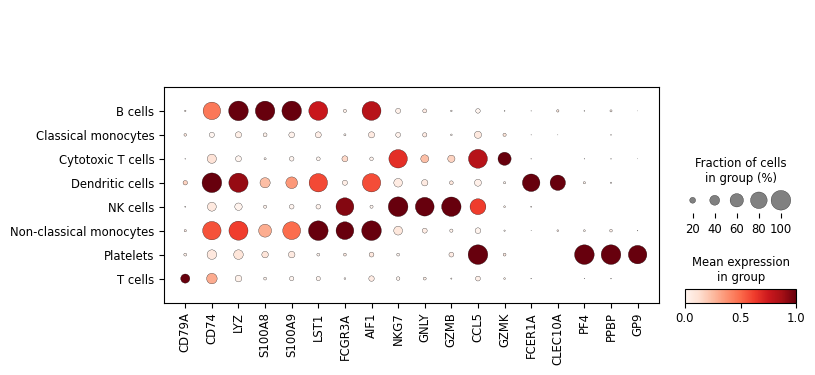

In [126]:
# Validate canonical cell-type markers in the current dataset

marker_genes = [
    "CD79A", "CD74",          # B cells
    "LYZ", "S100A8", "S100A9", # Classical monocytes
    "LST1", "FCGR3A", "AIF1",  # Non-classical monocytes
    "NKG7", "GNLY", "GZMB",   # NK cells
    "CCL5", "GZMK",           # Cytotoxic T cells
    "FCER1A", "CLEC10A",      # Dendritic cells
    "PF4", "PPBP", "GP9"      # Platelets
]

# Keep only genes actually present
available_markers = [g for g in marker_genes if g in adata.var_names]

print("Available markers:")
print(available_markers)

# Plot their expression across the annotated cell types
sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby="cell_type",
    standard_scale="var",
    dendrogram=False
)

In [127]:
import pandas as pd

marker_sets = {
    "B cells": ["CD79A", "CD74"],
    "Classical monocytes": ["LYZ", "S100A8", "S100A9"],
    "Non-classical monocytes": ["LST1", "FCGR3A", "AIF1"],
    "NK cells": ["NKG7", "GNLY", "GZMB"],
    "Cytotoxic T cells": ["CCL5", "GZMK"],
    "Dendritic cells": ["FCER1A", "CLEC10A"],
    "Platelets": ["PF4", "PPBP", "GP9"],
    "T cells": ["CD2", "LTB", "GIMAP7"]
}

rows = []

for cell_type, genes in marker_sets.items():
    genes = [g for g in genes if g in adata.var_names]

    for gene in genes:
        values = adata[:, gene].X

        if hasattr(values, "toarray"):
            values = values.toarray().flatten()
        else:
            values = values.flatten()

        temp = pd.DataFrame({
            "Cell Type": adata.obs["cell_type"].values,
            "Expression": values
        })

        mean_values = temp.groupby("Cell Type")["Expression"].mean()

        for current_type, value in mean_values.items():
            rows.append([
                cell_type,
                gene,
                current_type,
                value
            ])

marker_validation = pd.DataFrame(
    rows,
    columns=["Expected Cell Type", "Marker", "Current Cell Type", "Mean Expression"]
)

display(marker_validation)

,Expected Cell Type,Marker,Current Cell Type,Mean Expression
0,B cells,CD79A,B cells,-0.354199
1,B cells,CD79A,Classical monocytes,-0.306283
2,B cells,CD79A,Cytotoxic T cells,-0.388013
3,B cells,CD79A,Dendritic cells,-0.218710
4,B cells,CD79A,NK cells,-0.378114
...,...,...,...,...
163,T cells,GIMAP7,Dendritic cells,-0.420899
164,T cells,GIMAP7,NK cells,0.380080
165,T cells,GIMAP7,Non-classical monocytes,-0.242209
166,T cells,GIMAP7,Platelets,-0.922665


In [128]:
print("Raw data available:", adata.raw is not None)
print("Layers available:", list(adata.layers.keys()))
print("X shape:", adata.X.shape)

Raw data available: False
Layers available: [None]
X shape: (2638, 2000)


In [129]:
print("Raw data available:", adata.raw is not None)
print("Layers available:", list(adata.layers.keys()))
print("X shape:", adata.X.shape)

Raw data available: False
Layers available: [None]
X shape: (2638, 2000)


In [130]:
print("Objects available in memory:")
print([x for x in dir() if not x.startswith("_")])

Objects available in memory:
['In', 'Out', 'adata', 'adata_raw', 'available_markers', 'cell_counts', 'cell_percentages', 'cell_type', 'cell_type_map', 'cell_type_summary', 'celltypes', 'cluster', 'cluster_counts', 'cluster_to_celltype', 'count_summary', 'current_type', 'exit', 'file', 'final_counts', 'final_percentages', 'final_summary', 'gene', 'gene_summary', 'genes', 'genes_to_plot', 'get_ipython', 'group', 'groups', 'mapping', 'marker_df', 'marker_df_correct', 'marker_genes', 'marker_sets', 'marker_summary', 'marker_table', 'marker_validation', 'markers_to_check', 'mean_values', 'mt_summary', 'np', 'os', 'pd', 'plt', 'project_files', 'quit', 'rank', 'result', 'rows', 'sc', 'score', 'size_mb', 'temp', 'umap', 'value', 'values']


In [131]:
print("adata_raw type:", type(adata_raw))
print("adata_raw shape:", adata_raw.shape)
print("adata_raw layers:", list(adata_raw.layers.keys()))
print("adata_raw raw available:", adata_raw.raw is not None)
print("adata_raw X min:", adata_raw.X.min())
print("adata_raw X max:", adata_raw.X.max())

adata_raw type: <class 'anndata.AnnData'>
adata_raw shape: (2700, 32738)
adata_raw layers: [None]
adata_raw raw available: False
adata_raw X min: 0.0
adata_raw X max: 419.0


In [132]:
print("adata cells:", adata.n_obs)
print("adata_raw cells:", adata_raw.n_obs)

print("\nFirst 5 adata cell IDs:")
print(adata.obs_names[:5].tolist())

print("\nFirst 5 adata_raw cell IDs:")
print(adata_raw.obs_names[:5].tolist())

print("\nCells from adata present in adata_raw:",
      adata.obs_names.isin(adata_raw.obs_names).sum())

adata cells: 2638
adata_raw cells: 2700

First 5 adata cell IDs:
['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']

First 5 adata_raw cell IDs:
['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']

Cells from adata present in adata_raw: 2638


In [133]:
# Extract the same 2,638 cells from the original unscaled count matrix
adata_counts = adata_raw[adata.obs_names].copy()

print("Filtered count matrix shape:", adata_counts.shape)
print("First 5 cell IDs:")
print(adata_counts.obs_names[:5].tolist())

Filtered count matrix shape: (2638, 32738)
First 5 cell IDs:
['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']


In [134]:
# Copy the cell-type annotations from the final analyzed object
adata_counts.obs["cell_type"] = adata.obs.loc[
    adata_counts.obs_names, "cell_type"
].values

print("Cell-type annotation added successfully.")
print("\nCell types:")
print(adata_counts.obs["cell_type"].value_counts())

print("\nMissing cell-type annotations:",
      adata_counts.obs["cell_type"].isna().sum())

Cell-type annotation added successfully.

Cell types:
cell_type
T cells                    950
Classical monocytes        523
B cells                    430
Cytotoxic T cells          328
Non-classical monocytes    208
NK cells                   150
Dendritic cells             36
Platelets                   13
Name: count, dtype: int64

Missing cell-type annotations: 0


In [136]:
print("adata.obs columns:")
print(adata.obs.columns.tolist())

adata.obs columns:
['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type']


In [137]:
print("Cluster → Cell Type mapping:\n")
print(adata.obs.groupby("leiden")["cell_type"].value_counts())

print("\n\nCluster counts:")
print(adata.obs["leiden"].value_counts().sort_index())

Cluster → Cell Type mapping:

leiden  cell_type              
0       T cells                    605
        Cytotoxic T cells            0
        Classical monocytes          0
        Non-classical monocytes      0
        NK cells                     0
                                  ... 
8       T cells                      0
        Classical monocytes          0
        Non-classical monocytes      0
        NK cells                     0
        B cells                      0
Name: count, Length: 72, dtype: int64


Cluster counts:
leiden
0    605
1    523
2    430
3    345
4    328
5    208
6    150
7     36
8     13
Name: count, dtype: int64


In [138]:
mapping_check = (
    adata.obs[["leiden", "cell_type"]]
    .drop_duplicates()
    .sort_values("leiden")
)

print(mapping_check.to_string(index=False))

leiden               cell_type
     0                 T cells
     1     Classical monocytes
     2                 B cells
     3                 T cells
     4       Cytotoxic T cells
     5 Non-classical monocytes
     6                NK cells
     7         Dendritic cells
     8               Platelets


In [139]:
print("Marker genes selected for validation:\n")

for cell_type, genes in marker_sets.items():
    print(f"\n{cell_type}:")
    print(genes)

Marker genes selected for validation:


B cells:
['CD79A', 'CD74']

Classical monocytes:
['LYZ', 'S100A8', 'S100A9']

Non-classical monocytes:
['LST1', 'FCGR3A', 'AIF1']

NK cells:
['NKG7', 'GNLY', 'GZMB']

Cytotoxic T cells:
['CCL5', 'GZMK']

Dendritic cells:
['FCER1A', 'CLEC10A']

Platelets:
['PF4', 'PPBP', 'GP9']

T cells:
['CD2', 'LTB', 'GIMAP7']


In [140]:
# Calculate mean raw expression and percentage of cells expressing each marker
marker_validation_raw = []

for cell_type, genes in marker_sets.items():
    cells = adata_counts.obs["cell_type"] == cell_type

    for gene in genes:
        if gene in adata_counts.var_names:
            values = adata_counts[cells, gene].X

            # Convert sparse matrix to 1D array if necessary
            if hasattr(values, "toarray"):
                values = values.toarray().flatten()
            else:
                values = np.asarray(values).flatten()

            marker_validation_raw.append({
                "Cell Type": cell_type,
                "Marker Gene": gene,
                "Mean Expression": round(float(values.mean()), 4),
                "% Cells Expressing": round(float((values > 0).mean() * 100), 2),
                "Cells in Type": int(cells.sum())
            })
        else:
            marker_validation_raw.append({
                "Cell Type": cell_type,
                "Marker Gene": gene,
                "Mean Expression": np.nan,
                "% Cells Expressing": np.nan,
                "Cells in Type": int(cells.sum())
            })

marker_validation_raw = pd.DataFrame(marker_validation_raw)

print(marker_validation_raw.to_string(index=False))

              Cell Type Marker Gene  Mean Expression  % Cells Expressing  Cells in Type
                B cells       CD79A           0.0349                3.26            430
                B cells        CD74           8.8953               93.49            430
    Classical monocytes         LYZ           0.8050               53.15            523
    Classical monocytes      S100A8           0.1262               11.47            523
    Classical monocytes      S100A9           0.2065               19.89            523
Non-classical monocytes        LST1          15.9183              100.00            208
Non-classical monocytes      FCGR3A           6.6587               87.50            208
Non-classical monocytes        AIF1          14.6106              100.00            208
               NK cells        NKG7          24.4600              100.00            150
               NK cells        GNLY          19.1867               94.00            150
               NK cells        G

In [141]:
# Unbiased marker discovery for each Leiden cluster
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    use_raw=False
)

print("Differential expression analysis completed.")

Differential expression analysis completed.


/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:461: 

In [142]:
# Show the top 10 marker genes for each Leiden cluster
marker_results = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

top_markers = (
    marker_results
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(10)
)

print(top_markers[
    ["group", "names", "scores", "logfoldchanges", "pvals_adj"]
].to_string(index=False))

group    names    scores  logfoldchanges     pvals_adj
    0    RPL13 21.307020             NaN  9.771854e-98
    0    RPS3A 20.790804             NaN  3.495012e-93
    0   RPS27A 19.685833             NaN  1.426069e-83
    0   MALAT1 19.019554             NaN  2.936985e-78
    0      LTB  9.908113             NaN  2.193317e-21
    0     SELL  7.820991             NaN  2.278666e-13
    0      MAL  7.586200             NaN  1.372600e-12
    0   GIMAP5  7.325872             NaN  9.307842e-12
    0  LDLRAP1  6.580368             NaN  1.564291e-09
    0  TRABD2A  6.012346             NaN  5.224490e-08
    1      LTB 19.727110             NaN  2.523631e-83
    1      CD2 12.333054             NaN  1.202479e-32
    1   GIMAP7 11.966600             NaN  8.860433e-31
    1   RPS27A 11.391226             NaN  7.114463e-28
    1      B2M 11.062440             NaN  2.544467e-26
    1     AQP3 10.458533             NaN  1.673908e-23
    1    RPL13  8.482228             NaN  1.767369e-15
    1    R

In [143]:
# Proposed biologically corrected annotation
corrected_mapping = {
    "0": "T cells",
    "1": "T cells",
    "2": "Classical monocytes",
    "3": "B cells",
    "4": "Cytotoxic T cells",
    "5": "Non-classical monocytes",
    "6": "NK cells",
    "7": "Dendritic cells",
    "8": "Platelets"
}

proposed_cell_types = adata.obs["leiden"].astype(str).map(corrected_mapping)

print("Proposed corrected cell-type counts:")
print(proposed_cell_types.value_counts())

print("\nProposed cluster → cell type:")
print(
    pd.DataFrame({
        "Leiden": adata.obs["leiden"],
        "Proposed_Cell_Type": proposed_cell_types
    }).drop_duplicates().sort_values("Leiden").to_string(index=False)
)

Proposed corrected cell-type counts:
leiden
T cells                    1128
Classical monocytes         430
B cells                     345
Cytotoxic T cells           328
Non-classical monocytes     208
NK cells                    150
Dendritic cells              36
Platelets                    13
Name: count, dtype: int64

Proposed cluster → cell type:
Leiden      Proposed_Cell_Type
     0                 T cells
     1                 T cells
     2     Classical monocytes
     3                 B cells
     4       Cytotoxic T cells
     5 Non-classical monocytes
     6                NK cells
     7         Dendritic cells
     8               Platelets


In [144]:
# Apply the biologically validated cell-type annotation
adata.obs["cell_type"] = proposed_cell_types.values

print("Corrected cell-type annotation applied successfully.\n")

print(adata.obs["cell_type"].value_counts())

print("\nFinal Leiden → Cell Type mapping:")
print(
    adata.obs[["leiden", "cell_type"]]
    .drop_duplicates()
    .sort_values("leiden")
    .to_string(index=False)
)

Corrected cell-type annotation applied successfully.

cell_type
T cells                    1128
Classical monocytes         430
B cells                     345
Cytotoxic T cells           328
Non-classical monocytes     208
NK cells                    150
Dendritic cells              36
Platelets                    13
Name: count, dtype: int64

Final Leiden → Cell Type mapping:
leiden               cell_type
     0                 T cells
     1                 T cells
     2     Classical monocytes
     3                 B cells
     4       Cytotoxic T cells
     5 Non-classical monocytes
     6                NK cells
     7         Dendritic cells
     8               Platelets


In [145]:
# Recalculate marker validation using corrected cell-type annotations
adata_counts.obs["cell_type"] = adata.obs.loc[
    adata_counts.obs_names, "cell_type"
].values

marker_validation_corrected = []

for cell_type, genes in marker_sets.items():
    cells = adata_counts.obs["cell_type"] == cell_type

    for gene in genes:
        if gene in adata_counts.var_names:
            values = adata_counts[cells, gene].X

            if hasattr(values, "toarray"):
                values = values.toarray().flatten()
            else:
                values = np.asarray(values).flatten()

            marker_validation_corrected.append({
                "Cell Type": cell_type,
                "Marker Gene": gene,
                "Mean Expression": round(float(values.mean()), 4),
                "% Cells Expressing": round(float((values > 0).mean() * 100), 2),
                "Cells in Type": int(cells.sum())
            })
        else:
            marker_validation_corrected.append({
                "Cell Type": cell_type,
                "Marker Gene": gene,
                "Mean Expression": np.nan,
                "% Cells Expressing": np.nan,
                "Cells in Type": int(cells.sum())
            })

marker_validation_corrected = pd.DataFrame(marker_validation_corrected)

print(marker_validation_corrected.to_string(index=False))

              Cell Type Marker Gene  Mean Expression  % Cells Expressing  Cells in Type
                B cells       CD79A           4.3159               93.62            345
                B cells        CD74          27.0696              100.00            345
    Classical monocytes         LYZ          45.8860              100.00            430
    Classical monocytes      S100A8          17.7372               99.07            430
    Classical monocytes      S100A9          33.1488               99.53            430
Non-classical monocytes        LST1          15.9183              100.00            208
Non-classical monocytes      FCGR3A           6.6587               87.50            208
Non-classical monocytes        AIF1          14.6106              100.00            208
               NK cells        NKG7          24.4600              100.00            150
               NK cells        GNLY          19.1867               94.00            150
               NK cells        G

In [146]:
# Create clean final marker validation table
final_marker_table = marker_validation_corrected.copy()

# Add validation status
def validation_status(row):
    pct = row["% Cells Expressing"]

    if pd.isna(pct):
        return "Marker not found"
    elif pct >= 80:
        return "Strong"
    elif pct >= 50:
        return "Moderate"
    else:
        return "Low"

final_marker_table["Validation"] = final_marker_table.apply(
    validation_status, axis=1
)

print(final_marker_table.to_string(index=False))

              Cell Type Marker Gene  Mean Expression  % Cells Expressing  Cells in Type Validation
                B cells       CD79A           4.3159               93.62            345     Strong
                B cells        CD74          27.0696              100.00            345     Strong
    Classical monocytes         LYZ          45.8860              100.00            430     Strong
    Classical monocytes      S100A8          17.7372               99.07            430     Strong
    Classical monocytes      S100A9          33.1488               99.53            430     Strong
Non-classical monocytes        LST1          15.9183              100.00            208     Strong
Non-classical monocytes      FCGR3A           6.6587               87.50            208     Strong
Non-classical monocytes        AIF1          14.6106              100.00            208     Strong
               NK cells        NKG7          24.4600              100.00            150     Strong
          

In [147]:
final_marker_table.to_csv(
    "final_marker_validation.csv",
    index=False
)

print("\nSaved: final_marker_validation.csv")


Saved: final_marker_validation.csv


In [148]:
# Save the corrected, final annotated scRNA-seq dataset
final_h5ad_path = "scRNAseq_final_annotated_corrected.h5ad"

adata.write(final_h5ad_path)

print("Final annotated dataset saved successfully!")
print("File:", final_h5ad_path)
print("Shape:", adata.shape)
print("Cell types:", adata.obs["cell_type"].nunique())

Final annotated dataset saved successfully!
File: scRNAseq_final_annotated_corrected.h5ad
Shape: (2638, 2000)
Cell types: 8


In [149]:
# Verify that the saved file can be opened
adata_final = sc.read_h5ad("scRNAseq_final_annotated_corrected.h5ad")

print("Loaded successfully:", adata_final.shape)
print("\nCell-type counts:")
print(adata_final.obs["cell_type"].value_counts())

print("\nUMAP available:", "X_umap" in adata_final.obsm)
print("PCA available:", "X_pca" in adata_final.obsm)

Loaded successfully: (2638, 2000)

Cell-type counts:
cell_type
T cells                    1128
Classical monocytes         430
B cells                     345
Cytotoxic T cells           328
Non-classical monocytes     208
NK cells                    150
Dendritic cells              36
Platelets                    13
Name: count, dtype: int64

UMAP available: True
PCA available: True


In [150]:
# Final cell-type composition summary

final_counts = (
    adata.obs["cell_type"]
    .value_counts()
    .rename_axis("Cell Type")
    .reset_index(name="Cell Count")
)

final_counts["Percentage"] = (
    final_counts["Cell Count"] / len(adata) * 100
).round(2)

print(final_counts.to_string(index=False))

# Save the final composition table
final_counts.to_csv("cell_type_composition_final.csv", index=False)

print("\nSaved: cell_type_composition_final.csv")

              Cell Type  Cell Count  Percentage
                T cells        1128       42.76
    Classical monocytes         430       16.30
                B cells         345       13.08
      Cytotoxic T cells         328       12.43
Non-classical monocytes         208        7.88
               NK cells         150        5.69
        Dendritic cells          36        1.36
              Platelets          13        0.49

Saved: cell_type_composition_final.csv


/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


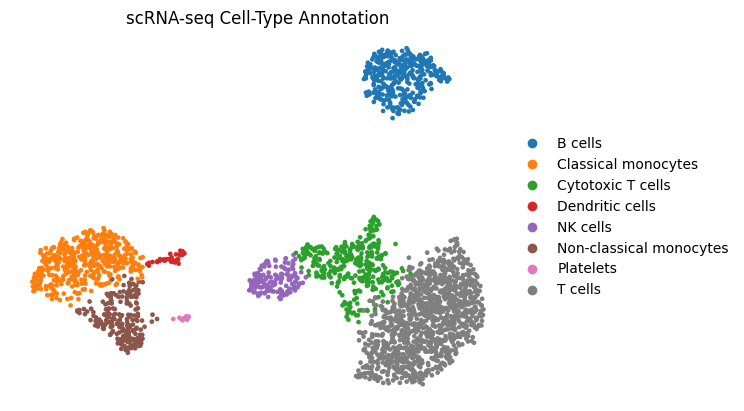

In [151]:
# Final UMAP using corrected cell-type annotations

sc.pl.umap(
    adata,
    color="cell_type",
    title="scRNA-seq Cell-Type Annotation",
    frameon=False,
    legend_loc="right margin"
)

/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


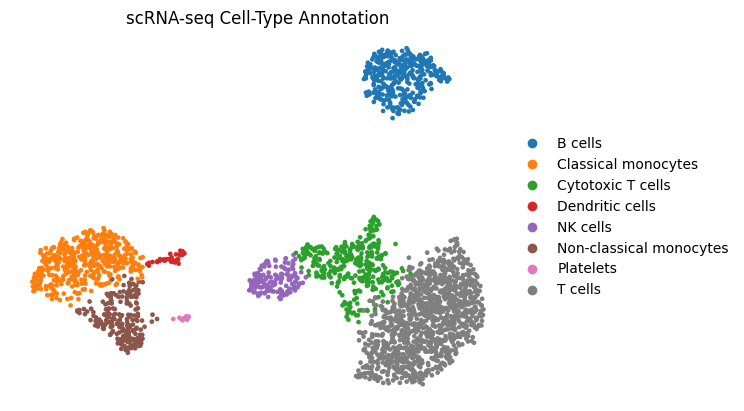

Saved: scRNAseq_final_UMAP_cell_types.png


In [152]:
# Save final corrected UMAP figure

sc.pl.umap(
    adata,
    color="cell_type",
    title="scRNA-seq Cell-Type Annotation",
    frameon=False,
    legend_loc="right margin",
    show=False
)

plt.savefig(
    "scRNAseq_final_UMAP_cell_types.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: scRNAseq_final_UMAP_cell_types.png")

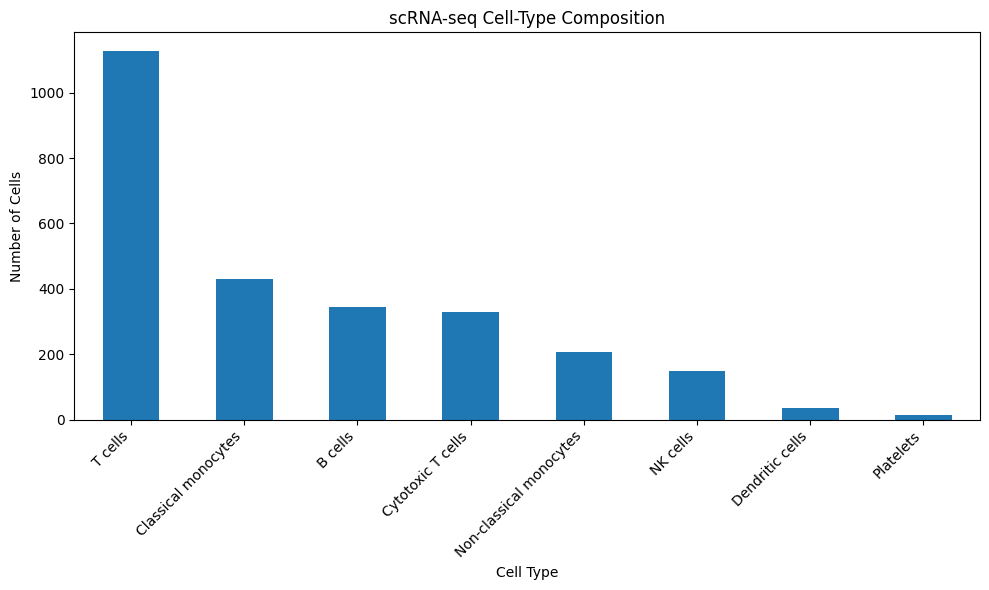

Saved: scRNAseq_cell_type_composition.png


In [153]:
import matplotlib.pyplot as plt

# Calculate cell-type counts
cell_type_counts = adata.obs["cell_type"].value_counts()

# Plot
plt.figure(figsize=(10, 6))
cell_type_counts.plot(kind="bar")

plt.title("scRNA-seq Cell-Type Composition")
plt.xlabel("Cell Type")
plt.ylabel("Number of Cells")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "scRNAseq_cell_type_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: scRNAseq_cell_type_composition.png")

In [154]:
print("========== FINAL scRNA-seq QC ==========")

print("\nDataset shape:")
print(adata.shape)

print("\nNumber of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

print("\nNumber of Leiden clusters:")
print(adata.obs["leiden"].nunique())

print("\nNumber of annotated cell types:")
print(adata.obs["cell_type"].nunique())

print("\nMissing cell-type annotations:")
print(adata.obs["cell_type"].isna().sum())

print("\nCell-type distribution:")
print(adata.obs["cell_type"].value_counts())

print("\nUMAP available:", "X_umap" in adata.obsm)
print("PCA available:", "X_pca" in adata.obsm)
print("Neighbors available:", "connectivities" in adata.obsp)

print("\n========================================")

========== FINAL scRNA-seq QC ==========

Dataset shape:
(2638, 2000)

Number of cells: 2638
Number of genes: 2000

Number of Leiden clusters:
9

Number of annotated cell types:
8

Missing cell-type annotations:
0

Cell-type distribution:
cell_type
T cells                    1128
Classical monocytes         430
B cells                     345
Cytotoxic T cells           328
Non-classical monocytes     208
NK cells                    150
Dendritic cells              36
Platelets                    13
Name: count, dtype: int64

UMAP available: True
PCA available: True
Neighbors available: True



In [155]:
import pandas as pd

project_summary = pd.DataFrame({
    "Metric": [
        "Cells analyzed",
        "Genes retained",
        "Leiden clusters",
        "Annotated cell types",
        "Missing annotations",
        "PCA dimensions",
        "UMAP dimensions"
    ],
    "Value": [
        adata.n_obs,
        adata.n_vars,
        adata.obs["leiden"].nunique(),
        adata.obs["cell_type"].nunique(),
        adata.obs["cell_type"].isna().sum(),
        adata.obsm["X_pca"].shape[1],
        adata.obsm["X_umap"].shape[1]
    ]
})

project_summary.to_csv(
    "scRNAseq_project_summary.csv",
    index=False
)

print(project_summary.to_string(index=False))
print("\nSaved: scRNAseq_project_summary.csv")

              Metric  Value
      Cells analyzed   2638
      Genes retained   2000
     Leiden clusters      9
Annotated cell types      8
 Missing annotations      0
      PCA dimensions     50
     UMAP dimensions      2

Saved: scRNAseq_project_summary.csv


In [156]:
import os

project_files = [
    "scRNAseq_final_annotated_corrected.h5ad",
    "final_marker_validation.csv",
    "cell_type_composition_final.csv",
    "scRNAseq_final_UMAP_cell_types.png",
    "scRNAseq_cell_type_composition.png",
    "scRNAseq_project_summary.csv"
]

print("========== FINAL PROJECT FILES ==========\n")

for file in project_files:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024 * 1024)
        print(f"✓ {file}  ({size_mb:.2f} MB)")
    else:
        print(f"✗ MISSING: {file}")

print("\n=========================================")

========== FINAL PROJECT FILES ==========

✓ scRNAseq_final_annotated_corrected.h5ad  (23.79 MB)
✓ final_marker_validation.csv  (0.00 MB)
✓ cell_type_composition_final.csv  (0.00 MB)
✓ scRNAseq_final_UMAP_cell_types.png  (0.29 MB)
✓ scRNAseq_cell_type_composition.png  (0.16 MB)
✓ scRNAseq_project_summary.csv  (0.00 MB)



In [157]:
from google.colab import files

final_files = [
    "scRNAseq_final_annotated_corrected.h5ad",
    "final_marker_validation.csv",
    "cell_type_composition_final.csv",
    "scRNAseq_final_UMAP_cell_types.png",
    "scRNAseq_cell_type_composition.png",
    "scRNAseq_project_summary.csv"
]

print("Preparing final project files...\n")

for file in final_files:
    print("✓", file)

print("\nStarting downloads...")

for file in final_files:
    files.download(file)

Preparing final project files...

✓ scRNAseq_final_annotated_corrected.h5ad
✓ final_marker_validation.csv
✓ cell_type_composition_final.csv
✓ scRNAseq_final_UMAP_cell_types.png
✓ scRNAseq_cell_type_composition.png
✓ scRNAseq_project_summary.csv

Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>